# Import the Libraries

In [2]:
import os
import json
import math
import glob
import shutil
import random
from pathlib import Path
from collections import defaultdict, Counter
import itertools
from itertools import combinations
import pycocotools.mask as mask_utils
from fnmatch import fnmatch
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy.stats import chi2_contingency, ks_2samp

# Matplotlib defaults (neutral and legible)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 120


import imagehash
from PIL import Image
from collections import defaultdict

# Import the Data

The dataset is stored in COCO-style JSON files (training.json, testing.json and patches_labels.json) together with the corresponding image folders. Each JSON file contains three tables:

- images: metadata for every image (file name, size, optional flags),

- annotations: bounding-box or segmentation labels linked by image_id, and

- categories: label definitions and their higher-level supercategory.

In [3]:
#BASE_DIR = Path(r"C:\Users\user\OneDrive - Università Commerciale Luigi Bocconi\CV").resolve()

BASE_DIR = Path(r"").resolve()
PATCHES_DIR = BASE_DIR / "patches"

TRAIN_JSON   = BASE_DIR / "training.json"
TEST_JSON    = BASE_DIR / "testing.json"
PATCHES_JSON = BASE_DIR / "patches_labels.json"

In [4]:
IMAGES_DIR_LOGICAL = "images"  # just a label for messages

# List the 7 real source folders that currently hold the images
SOURCE_DIRS = [
    BASE_DIR / "images0",
    BASE_DIR / "images1",
    BASE_DIR / "images2",
    BASE_DIR / "images3",
    BASE_DIR / "images4",
    BASE_DIR / "images5",
    BASE_DIR / "images6",
]

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

# --- Build an index of all images found across the 7 folders ---
# Keys we support:
#   1) exact relative path (relative to each source dir), e.g. "classX/img001.jpg"
#   2) basename only, e.g. "img001.jpg" (collision-safe: we’ll raise if ambiguous)
path_index = {}         # e.g. "classX/img.jpg" -> absolute path string (unique per file)
basename_index = {}     # e.g. "img.jpg" -> list of absolute path strings (for collision detect)

def add_to_index(root: Path, file_path: Path):
    rel = file_path.relative_to(root).as_posix()
    abs_str = str(file_path.resolve())

    # exact relative (first match wins; order of SOURCE_DIRS matters)
    if rel not in path_index:
        path_index[rel] = abs_str

    # basename (may collide)
    base = file_path.name
    basename_index.setdefault(base, []).append(abs_str)

for src in SOURCE_DIRS:
    if not src.exists():
        print(f"WARNING: missing source dir -> {src}")
        continue
    for p in src.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            add_to_index(src, p)

# --- A tiny "virtual directory" that resolves on division ---
class VirtualDir:
    """
    Behaves like a directory for expressions such as: VDIR / 'file_name'
    Returns a real pathlib.Path pointing to the actual file across SOURCE_DIRS.
    """

    def __init__(self, label: str):
        self.label = label

    def _resolve(self, key: str) -> Path:
        norm = str(key).replace("\\", "/")

        # 1) Exact relative path match first
        if norm in path_index:
            return Path(path_index[norm])

        # 2) Basename fallback (must be unambiguous)
        base = norm.split("/")[-1]
        matches = basename_index.get(base, [])
        if not matches:
            raise FileNotFoundError(
                f"[{self.label}] Not found: {key}. "
                "If this filename exists in subfolders, include its subpath in file_name."
            )
        if len(matches) > 1:
            samples = "\n  - " + "\n  - ".join(matches[:5]) + (
                "" if len(matches) <= 5 else f"\n  ... (+{len(matches)-5} more)"
            )
            raise FileExistsError(
                f"[{self.label}] Ambiguous basename '{base}' found in multiple folders. "
                f"Update file_name to include subfolder (e.g., 'classX/{base}'). Candidates:{samples}"
            )
        return Path(matches[0])

    # Support the "IMAGES_DIR / 'name.jpg'" pattern
    def __truediv__(self, key):
        return self._resolve(str(key))

    # Some libs call joinpath
    def joinpath(self, *parts):
        return self._resolve("/".join(map(str, parts)))

    # --- Compatibility helpers for .exists(), .glob(), etc. ---
    def exists(self) -> bool:
        """Pretend the virtual directory exists."""
        return True

    def glob(self, pattern="*"):
        """
        Iterate unique absolute Paths matching pattern.
        Uses path_index (one entry per file) to avoid double-counting
        that would arise from also iterating basename_index.
        """
        seen = set()
        for rel, abs_str in path_index.items():  # one-to-one mapping
            # Match against the relative path and its basename
            if fnmatch(rel, pattern) or fnmatch(Path(rel).name, pattern):
                if abs_str not in seen:
                    seen.add(abs_str)
                    yield Path(abs_str)

    def rglob(self, pattern="*"):
        """Alias for glob() since the virtual view is flat."""
        yield from self.glob(pattern)

    def iterdir(self):
        """Return all unique Paths (one per real file)."""
        for abs_path in set(path_index.values()):
            yield Path(abs_path)

    def __repr__(self):
        return f"<VirtualDir '{self.label}' with {len(path_index)} indexed images>"

# ---- Expose the virtual dir under the name your code already uses ----
IMAGES_DIR = VirtualDir(IMAGES_DIR_LOGICAL)

print(f"Virtual image view ready over {len(SOURCE_DIRS)} folders.")
print(f"Indexed {len(set(path_index.values()))} unique images.")
print("Keep using:  IMAGES_DIR / image['file_name']")


Virtual image view ready over 7 folders.
Indexed 11703 unique images.
Keep using:  IMAGES_DIR / image['file_name']


In [5]:
def read_json(path: Path):
    """Load JSON if it exists, else return None (keeps notebook robust)."""
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

# Convert string paths to Path objects
train_data = read_json(Path(TRAIN_JSON))
test_data  = read_json(Path(TEST_JSON))
patches_data = read_json(Path(PATCHES_JSON))

In [6]:
# Pick a main source for categories/images/annotations.
def extract_coco_triplet(d):
    """Return (images, annotations, categories) from a COCO-like dict, or empty lists."""
    if not d: 
        return [], [], []
    return d.get("images", []), d.get("annotations", []), d.get("categories", [])

train_images, train_anns, train_cats = extract_coco_triplet(train_data)
test_images,  test_anns,  test_cats  = extract_coco_triplet(test_data)

For most exploratory statistics we merge the training and testing annotations into a single working set. This approach yields a global understanding of class balance, annotation quality, and labeling consistency across the entire dataset. Split-specific checks (e.g., leakage) are performed separately later to ensure no information contamination occurs between training and evaluation data.

In [7]:
# Merge train/test tables to form a "working view" of the labeled universe
images_all = {im["id"]: im for im in train_images}
images_all.update({im["id"]: im for im in test_images})
images_all = list(images_all.values())

annotations_all = list(train_anns) + list(test_anns)

In [8]:
# Prefer categories from train.json; fall back to test.json if train is empty.
cats = train_cats if len(train_cats) else test_cats

In [9]:
# Build lookup helpers
cat_by_id = {c["id"]: c for c in cats} if cats else {}
img_by_id = {im["id"]: im for im in images_all}
ann_by_img = defaultdict(list)
for a in annotations_all:
    ann_by_img[a["image_id"]].append(a)

We create fast lookup dictionaries (cat_by_id, img_by_id, ann_by_img) to efficiently connect category, image, and annotation metadata within the COCO-style structure. These mappings allow instant access to category names, image dimensions, and per-image annotations, which are required for all subsequent EDA and visualization steps.

In [10]:
# On-screen summary
summary = {
    "train_json_present": train_data is not None,
    "test_json_present": test_data is not None,
    "patches_json_present": patches_data is not None,
    "n_train_images_in_json": len(train_images),
    "n_test_images_in_json": len(test_images),
    "n_images_merged_json": len(images_all),
    "n_annotations_merged_json": len(annotations_all),
    "n_categories": len(cats),
    "images_dir_exists": IMAGES_DIR.exists(),
    "patches_dir_exists": PATCHES_DIR.exists(),
    "n_images_on_disk": sum(1 for _ in IMAGES_DIR.glob("*.*")) if IMAGES_DIR.exists() else 0,
    "n_patches_on_disk": sum(1 for _ in PATCHES_DIR.glob("*.*")) if PATCHES_DIR.exists() else 0,
}
display(pd.DataFrame([summary]).T.rename(columns={0: "value"}))

,value
train_json_present,True
test_json_present,True
patches_json_present,True
n_train_images_in_json,9096
n_test_images_in_json,2607
n_images_merged_json,11703
n_annotations_merged_json,833
n_categories,22
images_dir_exists,True
patches_dir_exists,True


# Conduct the Eda

### Preliminary Visual Inspection

Before quantitative analysis, we conduct a brief visual inspection to ensure images load as expected and align with metadata assumptions. We (i) list random filenames, (ii) display a small grid of random images, and (iii) estimate typical dimensions from disk. This step helps catch path issues, corrupted files, or unexpected color/format anomalies early.

In [11]:
# 1) Report a few random filenames in the images directory
image_files = sorted(IMAGES_DIR.glob("*.*"))
print(f"Found {len(image_files)} image files in: {IMAGES_DIR}")
print("Random 5 image filenames:")
for f in random.sample(image_files, min(5, len(image_files))):
    print("  ", f.name)

Found 11703 image files in: <VirtualDir 'images' with 11703 indexed images>
Random 5 image filenames:
   8.png
   8539.png
   5021.png
   2020.png
   6147.png


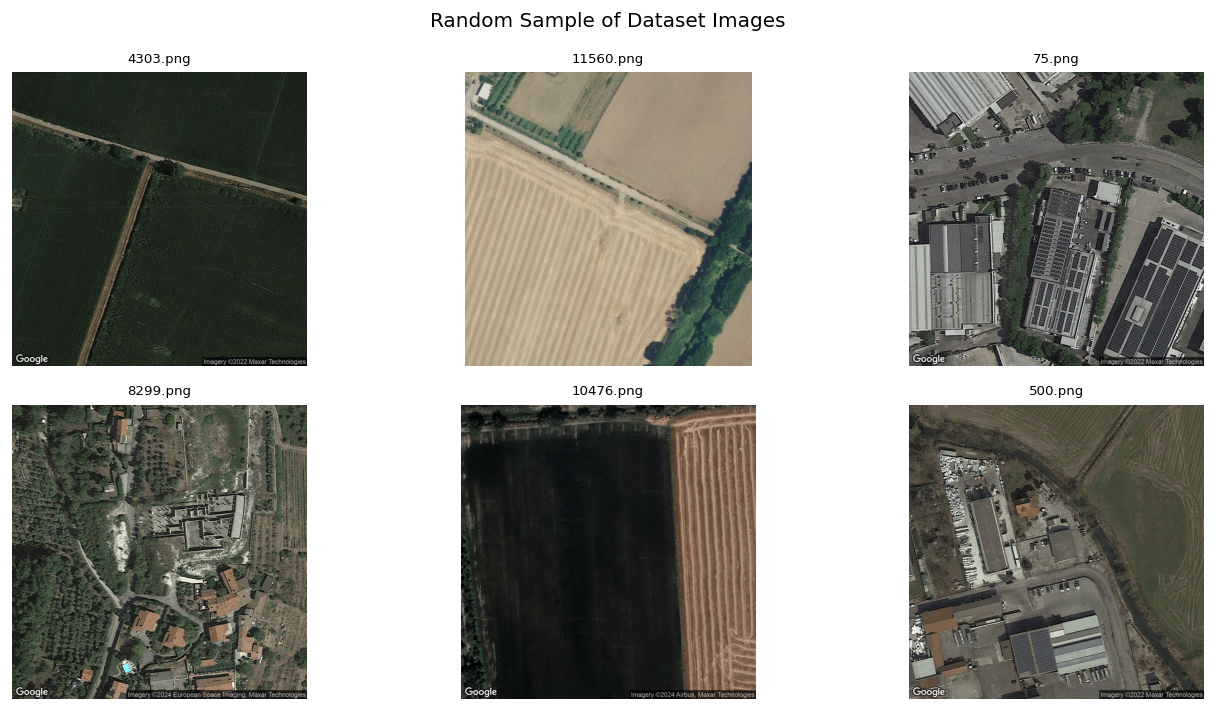

In [12]:
# 2) Display a small grid of random images
n_show = 6
sample_paths = random.sample(image_files, min(n_show, len(image_files)))
cols = math.ceil(n_show / 2)
fig, axes = plt.subplots(2, cols, figsize=(12, 6))
axes = axes.flatten()

for ax, p in zip(axes, sample_paths):
    try:
        im = Image.open(p)
        ax.imshow(im)
        ax.set_title(p.name, fontsize=8)
        ax.axis("off")
    except Exception as e:
        ax.set_visible(False)
        print(f"Could not open {p.name}: {e}")

for ax in axes[len(sample_paths):]:
    ax.axis("off")

plt.suptitle("Random Sample of Dataset Images", fontsize=12)
plt.tight_layout()
plt.show()

In [13]:
# 3) Estimate typical image size from a random subset (from disk, not JSON)
sizes = []
for p in random.sample(image_files, min(50, len(image_files))):
    try:
        with Image.open(p) as im:
            sizes.append(im.size)  # (width, height)
    except:
        pass

if sizes:
    widths, heights = zip(*sizes)
    print(f"Average width: {np.mean(widths):.1f} px | Average height: {np.mean(heights):.1f} px")


Average width: 1006.2 px | Average height: 1006.0 px


### Split Integrity & Leakage Check

Verify that training.json and testing.json are disjoint and consistent with the image files on disk. We detect any overlapping image IDs (leakage) and list missing files referenced by the JSONs. Ensuring clean separation prevents optimistic evaluation and preserves experimental validity.

In [14]:
train_ids = {im["id"] for im in train_images}
test_ids  = {im["id"] for im in test_images}

In [15]:
overlap = sorted(train_ids.intersection(test_ids))
print(f"Train images in JSON: {len(train_ids)}")
print(f"Test images in JSON:  {len(test_ids)}")
print(f"Overlap (should be 0): {len(overlap)}")
if overlap:
    print("Overlapping image IDs (sample up to 20):", overlap[:20])

Train images in JSON: 9096
Test images in JSON:  2607
Overlap (should be 0): 0


In [16]:
# Check existence of referenced files on disk (images/)
def missing_files(images, base_dir=IMAGES_DIR):
    missing = []
    for im in images:
        fname = im.get("file_name", "")
        path = base_dir / fname
        if not path.exists():
            missing.append(fname)
    return missing

miss_train = missing_files(train_images)
miss_test  = missing_files(test_images)


In [17]:
print(f"Missing files in TRAIN (count): {len(miss_train)}")
if miss_train:
    print("  Sample missing (up to 20):", miss_train[:20])

print(f"Missing files in TEST  (count): {len(miss_test)}")
if miss_test:
    print("  Sample missing (up to 20):", miss_test[:20])

Missing files in TRAIN (count): 0
Missing files in TEST  (count): 0


### Duplicate / Near-Duplicate Detection

Identify exact and near-duplicate images to prevent train/val/test leakage and over-optimistic metrics. We compute perceptual hashes (pHash and aHash) for all images, group images whose Hamming distance is ≤ 5 (configurable), and summarize duplicate clusters both within each split and across splits. The across-split count is a high-risk indicator of evaluation leakage. This analysis is robust to minor resizes or compression changes and helps decide whether to deduplicate or quarantine suspect items before model training and validation.

In [18]:
THRESH = 5  # Hamming distance threshold for "near-duplicate"

In [19]:
# Helper: build filename -> split map from the JSONs
train_fnames = {im.get("file_name", "") for im in train_images}
test_fnames  = {im.get("file_name", "") for im in test_images}
split_of = {}
for fn in train_fnames:
    split_of[fn] = "train"
for fn in test_fnames:
    # if a file appears in both (shouldn't), mark as "both"
    split_of[fn] = "test" if fn not in split_of else "both"

In [20]:
# 1) Hash all images in IMAGES_DIR
paths = sorted([p for p in IMAGES_DIR.glob("*.*") if p.is_file()])
print(f"Hashing {len(paths)} images (this may take a bit)...")

hash_records = []
for p in paths:
    try:
        with Image.open(p) as im:
            # Convert to RGB to be consistent
            im = im.convert("RGB")
            ph = imagehash.phash(im)   # robust to small transforms
            ah = imagehash.average_hash(im)
            hash_records.append({
                "file_name": p.name,
                "phash": str(ph),
                "ahash": str(ah)
            })
    except Exception as e:
        print(f"Failed to hash {p.name}: {e}")

df_hash = pd.DataFrame(hash_records)
display(df_hash.head())

Hashing 11703 images (this may take a bit)...


,file_name,phash,ahash
0,10.png,9b9b2226dc29ed25,0f0c0e1c1e2220f0
1,1001.png,aa5355ab561dab41,00c1211f07031387
2,10010.png,c54ab58f4a85ce1e,f0e0f0f0b0f2f2e2
3,10014.png,89e639be3f071425,875b7f3f371f1b0b
4,10015.png,d85e2f81c07a9f4a,000080f0fc1f0340


In [21]:
# 2) Build clusters using pHash first; use a simple union-find via greedy grouping
def hamming(a, b):
    # imagehash objects support (a - b) to get Hamming distance when objects
    return imagehash.hex_to_hash(a) - imagehash.hex_to_hash(b)

visited = set()
clusters = []
for i, row in df_hash.iterrows():
    if i in visited: 
        continue
    group_idx = [i]
    visited.add(i)
    for j in range(i+1, len(df_hash)):
        if j in visited:
            continue
        if hamming(df_hash.iloc[i]["phash"], df_hash.iloc[j]["phash"]) <= THRESH:
            group_idx.append(j)
            visited.add(j)
    clusters.append(group_idx)

In [22]:
# Convert clusters to a readable table (only clusters with size >= 2)
cluster_rows = []
for cidx, idxs in enumerate(clusters, start=1):
    if len(idxs) < 2:
        continue
    files = [df_hash.iloc[k]["file_name"] for k in idxs]
    # representative = the first filename
    rep = files[0]
    # splits involved
    splits = sorted({split_of.get(fn, "unknown") for fn in files})
    cross_split = ("train" in splits and "test" in splits) or ("both" in splits)
    cluster_rows.append({
        "cluster_id": cidx,
        "size": len(files),
        "representative": rep,
        "members": files,
        "splits": splits,
        "cross_split_duplicate": int(cross_split)
    })

df_clusters = pd.DataFrame(cluster_rows).sort_values(["cross_split_duplicate","size"], ascending=[False, False])
display(df_clusters)

,cluster_id,size,representative,members,splits,cross_split_duplicate
8,5242,4,11309.png,"[11309.png, 6510.png, 3694.png, 5015.png]","[test, train]",1
6,2788,3,6459.png,"[6459.png, 5517.png, 4812.png]","[test, train]",1
2,951,4,5527.png,"[5527.png, 6585.png, 5256.png, 5021.png]",[train],0
3,1537,3,9160.png,"[9160.png, 9503.png, 6743.png]",[train],0
0,27,2,10130.png,"[10130.png, 2794.png]",[train],0
1,897,2,5144.png,"[5144.png, 5188.png]",[train],0
4,1545,2,9214.png,"[9214.png, 10594.png]",[train],0
5,2646,2,5518.png,"[5518.png, 5507.png]",[train],0
7,3418,2,10492.png,"[10492.png, 5490.png]",[test],0


In [23]:
# Quick summary
n_clusters = (df_clusters["size"] >= 2).sum() if not df_clusters.empty else 0
n_cross = df_clusters["cross_split_duplicate"].sum() if not df_clusters.empty else 0
print(f"Duplicate clusters (size >= 2): {n_clusters}")
print(f"Cross-split duplicate clusters: {n_cross}  <-- potential leakage")

Duplicate clusters (size >= 2): 9
Cross-split duplicate clusters: 2  <-- potential leakage


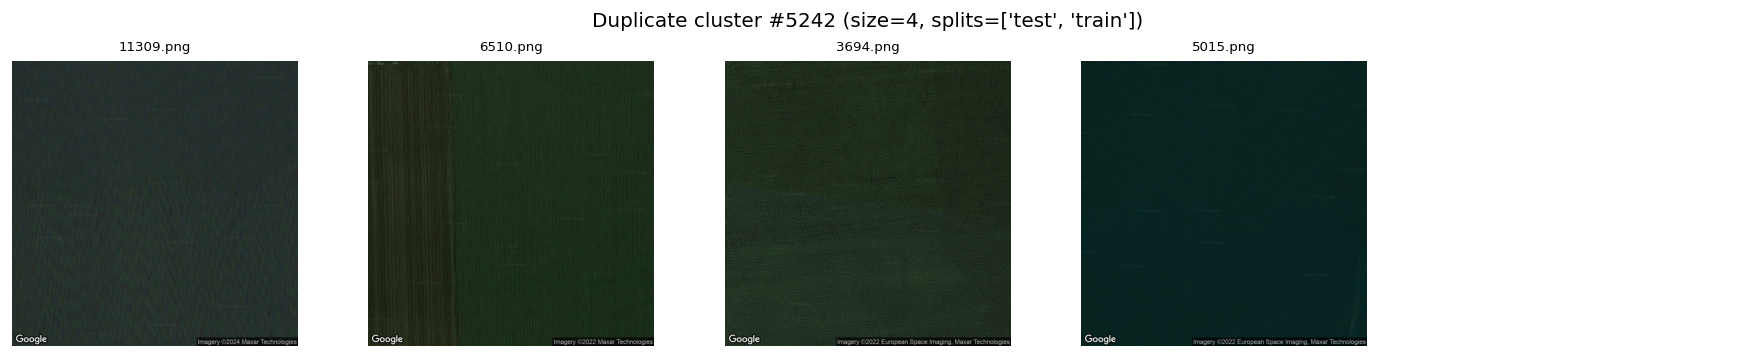

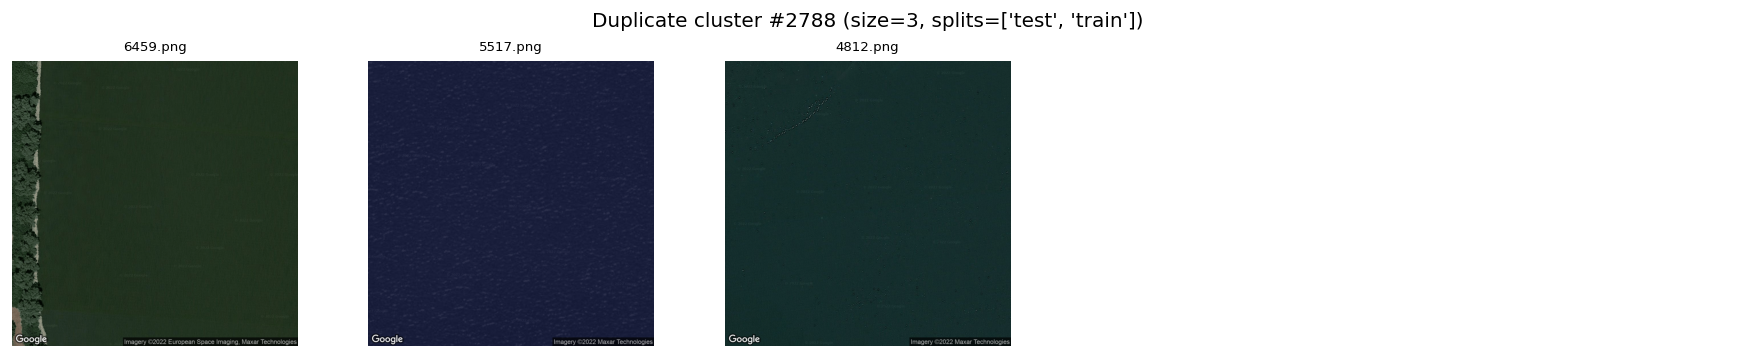

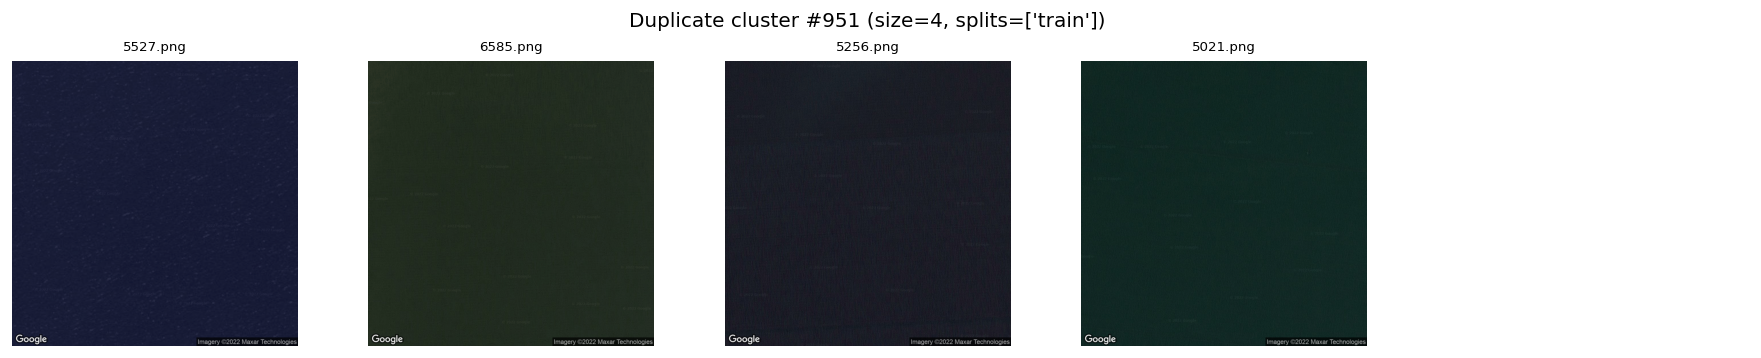

In [24]:
# Show the first few clusters inline (small thumbnails)
def show_cluster(files, cols=5, max_imgs=10, title="Cluster preview"):
    sample = files[:max_imgs]
    rows = math.ceil(len(sample) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = np.array(axes).reshape(-1) if isinstance(axes, np.ndarray) else [axes]
    for ax, fn in zip(axes, sample):
        p = IMAGES_DIR / fn
        try:
            im = Image.open(p)
            ax.imshow(im)
            ax.set_title(fn, fontsize=8)
            ax.axis("off")
        except:
            ax.axis("off")
    for ax in axes[len(sample):]:
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

if not df_clusters.empty:
    for _, r in df_clusters.head(3).iterrows():
        show_cluster(r["members"], title=f"Duplicate cluster #{int(r['cluster_id'])} (size={int(r['size'])}, splits={r['splits']})")

### Coverage & Labeling Status

This section quantifies the size and annotation coverage of the dataset using its COCO-style JSON structure (the common format containing images, annotations, and categories). The analysis counts the total number of images referenced, determines how many contain at least one annotated object (labeled) versus none (unlabeled), and reports the same statistics for each data split (training and testing). These measures establish how much of the available imagery actually provides supervision for object-detection learning and clarify the ratio between positive and negative samples.

In [25]:
def image_label_status(images, ann_by_img):
    """Return a DataFrame indicating whether each image has annotations and how many."""
    rows = []
    for im in images:
        n = len(ann_by_img.get(im["id"], []))
        rows.append({
            "image_id": im["id"],
            "file_name": im.get("file_name", ""),
            "has_annotations": int(n > 0),
            "num_annotations": n
        })
    return pd.DataFrame(rows)

In [26]:
df_all = image_label_status(images_all, ann_by_img)
train_img_ids = {im["id"] for im in train_images}
test_img_ids  = {im["id"] for im in test_images}

df_train = df_all[df_all["image_id"].isin(train_img_ids)].copy()
df_test  = df_all[df_all["image_id"].isin(test_img_ids)].copy()

In [27]:
coverage = {
    "all_images_json": len(images_all),
    "all_labeled_images": int(df_all["has_annotations"].sum()),
    "all_unlabeled_images": int((1 - df_all["has_annotations"]).sum()),
    "train_images_json": len(train_images),
    "train_labeled_images": int(df_train["has_annotations"].sum()),
    "test_images_json": len(test_images),
    "test_labeled_images": int(df_test["has_annotations"].sum()),
}
coverage["%_labeled_all"] = 100.0 * coverage["all_labeled_images"] / max(coverage["all_images_json"], 1)

display(pd.DataFrame([coverage]).T.rename(columns={0: "value"}))

,value
all_images_json,11703.00000
all_labeled_images,166.00000
all_unlabeled_images,11537.00000
train_images_json,9096.00000
train_labeled_images,0.00000
test_images_json,2607.00000
test_labeled_images,166.00000
%_labeled_all,1.41844


The dataset comprises 11,703 unique images (training: 9,096; testing: 2,607), of which only 166 images contain at least one object annotation, all within the testing split. Consequently, 11,537 images are currently unlabeled, yielding an overall label coverage of ~1.42%. This indicates a sparse-supervision scenario for full images: the majority of raw imagery cannot directly support supervised detector training without additional labeling.

**Why this matters**

Training a box-first detector on full images alone is not viable given the extremely limited labeled subset.

Using the small labeled subset directly as train/val risks overfitting and unstable evaluation, unless splits are carefully engineered and regularization is strong.

Strategy going forward: train on patches derived from segmentations

We will train on the patches/ dataset (≈ 3,092 crops, ≈ 800 labeled), which originates from segmentation work performed in a separate notebook on the 166 labeled images.


### Image-Level Metadata Quality

Assess the consistency of image metadata and identify potential sources of dataset bias that could affect training and evaluation. We analyze the distributions of resolution (width, height) and aspect ratio to detect atypical sizes or imaging conditions. We then summarize key categorical metadata—site_type, severity, valid_fine_grain, evidence, and is_candidate_location—to understand how scenes and labeling flags are represented. Finally, we cross-tabulate site_type with annotation presence (labeled vs. unlabeled images) to test for labeling bias, i.e., whether certain site types are disproportionately labeled or ignored. These checks help ensure that model performance is not driven by hidden imbalances in capture conditions or annotation practices.

In [28]:
img_meta = []
for im in images_all:
    w = im.get("width", np.nan)
    h = im.get("height", np.nan)
    ar = (w / h) if (w and h and h != 0) else np.nan
    img_meta.append({
        "image_id": im["id"],
        "file_name": im.get("file_name", ""),
        "width": w,
        "height": h,
        "aspect_ratio": ar,
        "site_type": im.get("site_type", None),
        "severity": im.get("severity", None),
        "valid_fine_grain": im.get("valid_fine_grain", None),
        "evidence": im.get("evidence", None),
        "is_candidate_location": im.get("is_candidate_location", None),
        "has_annotations": int(len(ann_by_img.get(im["id"], [])) > 0),
        "num_annotations": len(ann_by_img.get(im["id"], []))
    })
df_meta = pd.DataFrame(img_meta)
display(df_meta.head())

,image_id,file_name,width,height,aspect_ratio,site_type,severity,valid_fine_grain,evidence,is_candidate_location,has_annotations,num_annotations
0,1,1.png,1000,1000,1.0,Production site,1,0,2,1,0,0
1,2,2.png,1000,1000,1.0,Degraded area,2,0,1,1,0,0
2,3,3.png,1000,1000,1.0,Degraded area,1,0,2,1,0,0
3,4,4.png,1000,1000,1.0,Production site,2,0,2,1,0,0
4,5,5.png,1000,1000,1.0,Production site,1,0,1,1,0,0


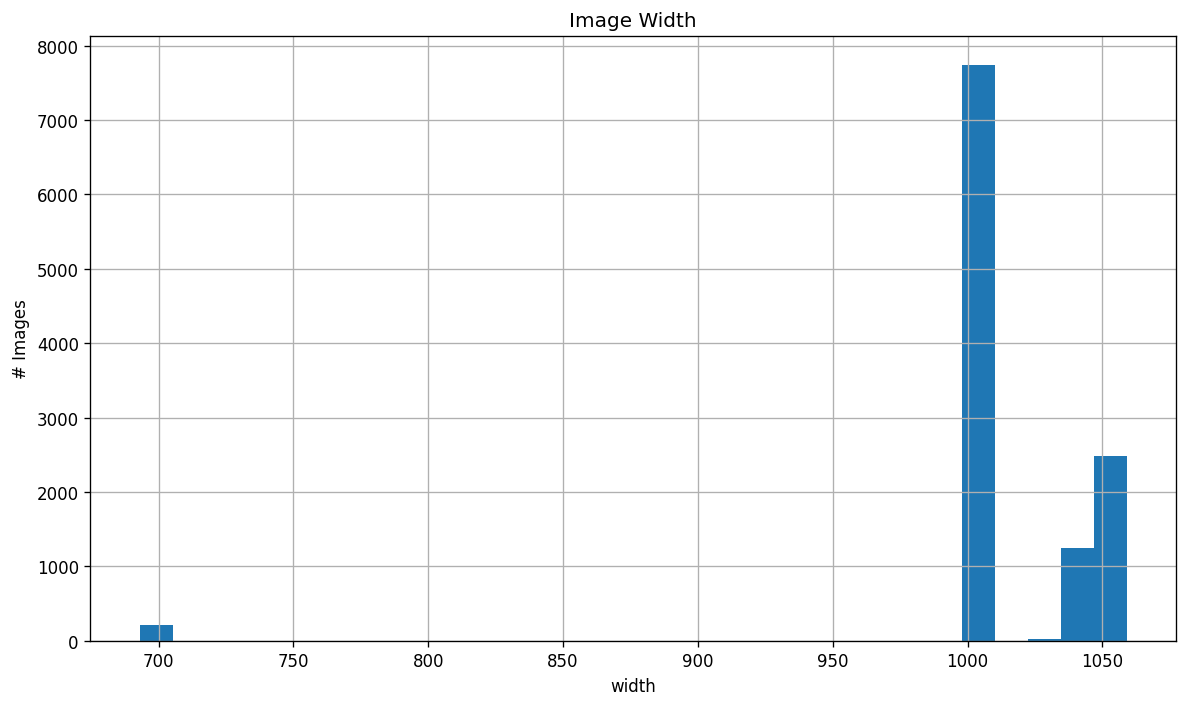

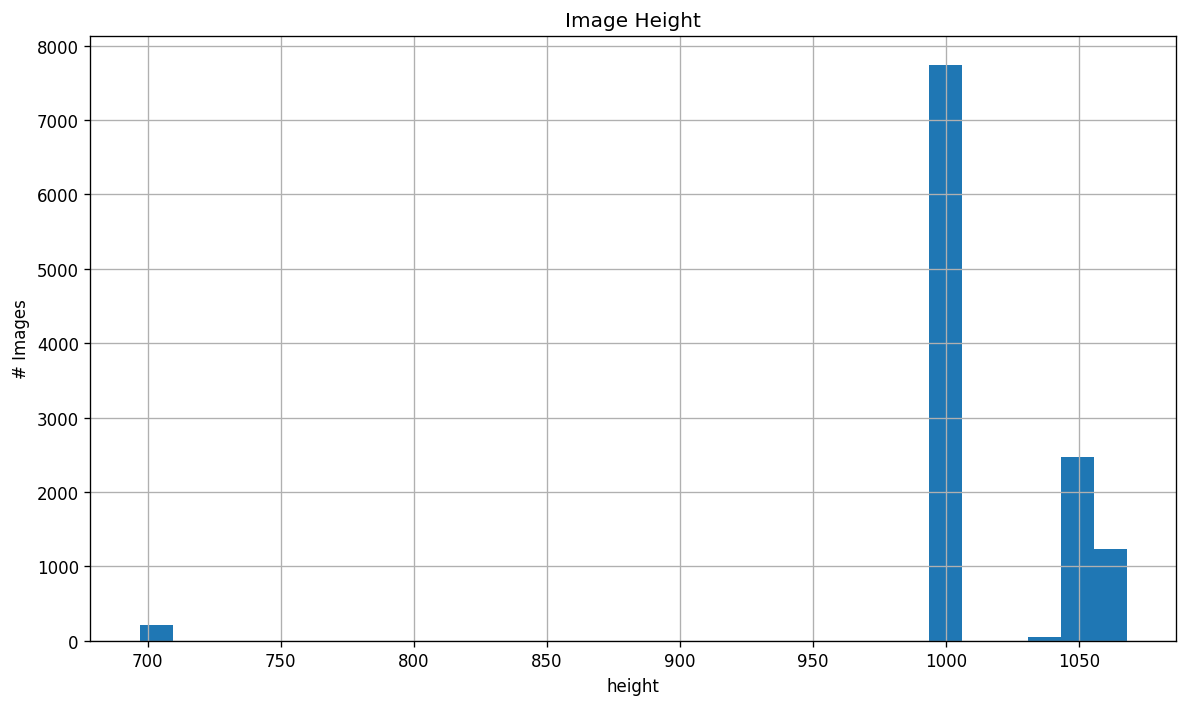

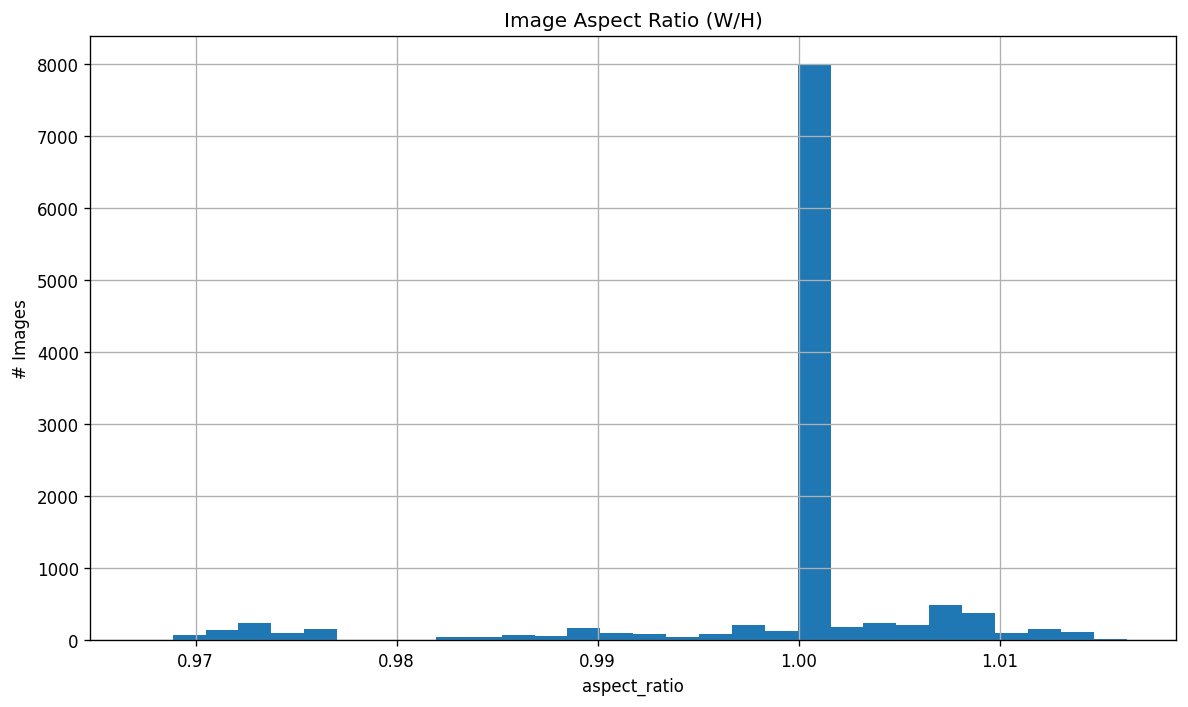

In [29]:
# Histograms: width, height, aspect ratio
for col, title in [("width", "Image Width"), ("height", "Image Height"), ("aspect_ratio", "Image Aspect Ratio (W/H)")]:
    vals = df_meta[col].dropna().values
    if len(vals):
        plt.figure()
        plt.hist(vals, bins=30)
        plt.title(title)
        plt.xlabel(col)
        plt.ylabel("# Images")
        plt.tight_layout()
        plt.show()

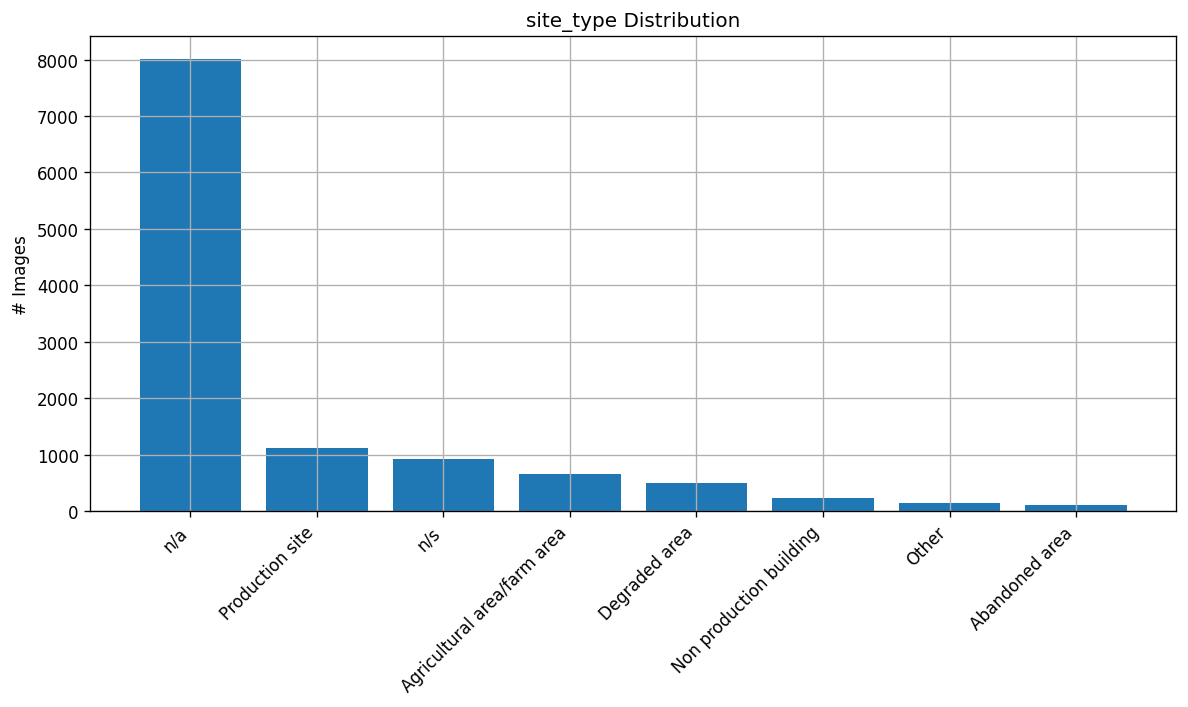

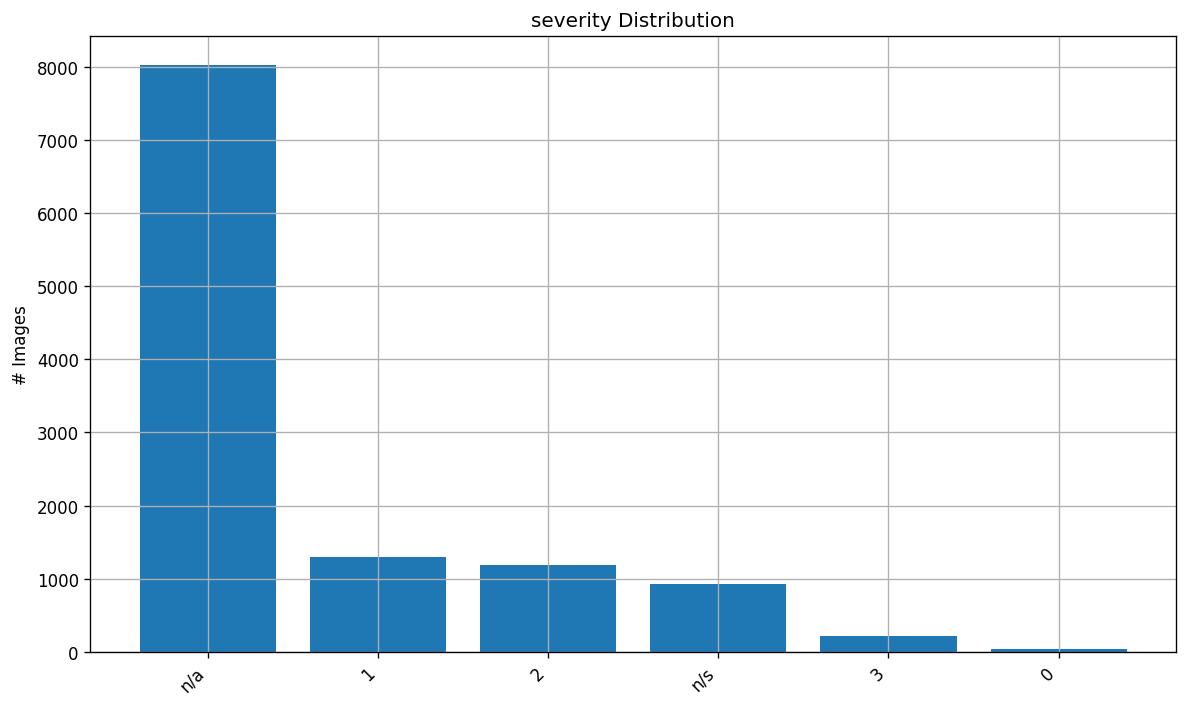

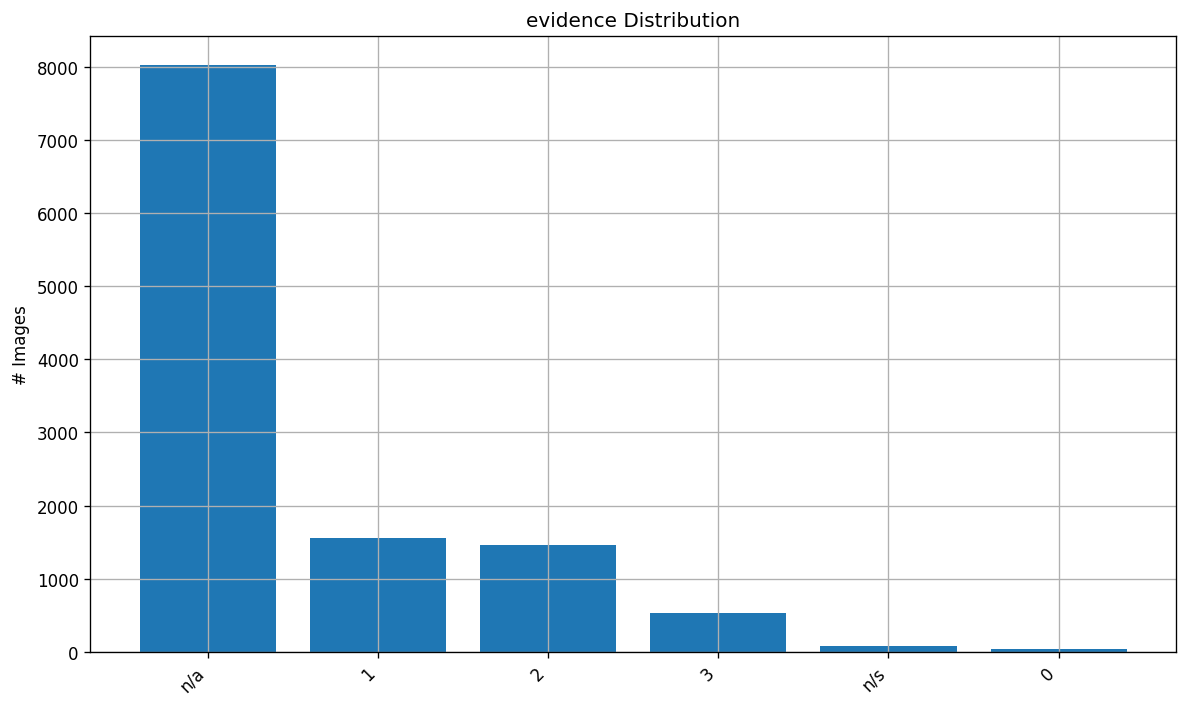

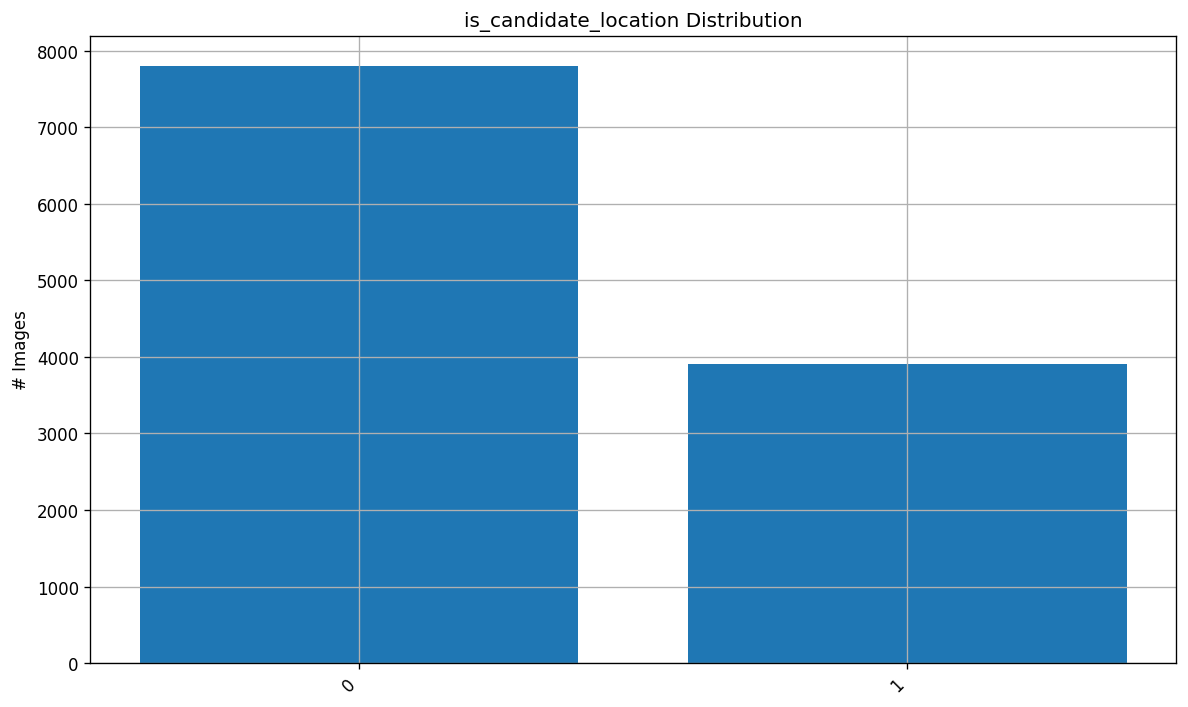

In [30]:
# Categorical bars
cat_cols = ["site_type", "severity", "evidence", "is_candidate_location"]
for col in cat_cols:
    counts = df_meta[col].value_counts(dropna=False)
    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"{col} Distribution")
    plt.ylabel("# Images")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

The dataset shows strong class imbalance across all categorical attributes:

- **site_type** — The majority of images (~8,000) are labeled as N/A, while Production site and Agricultural area are the next most frequent categories. Other types (e.g., Degraded area, Non-production building, Abandoned area) are underrepresented.

- **severity** — Most entries are N/A, with relatively few labeled 1 or 2, and very few high-severity (3) or zero-severity (0) cases.

- **evidence** — Similarly skewed toward N/A, followed by levels 1–3, with negligible counts for 0.

- **is_candidate_location** — Approximately two-thirds of samples are non-candidates (0), while one-third are marked as candidates (1).

Overall, the dataset is heavily imbalanced, with N/A dominating several attributes. Any model training or evaluation will likely require rebalancing or weighting strategies.

In [31]:
# Cross-tab: site_type × has_annotations? (labeling bias)
if "site_type" in df_meta.columns:
    ctab = pd.crosstab(df_meta["site_type"].fillna("Unknown"), df_meta["has_annotations"])
    display(ctab)
    if ctab.shape[0] > 1 and ctab.shape[1] > 1:
        chi2, p, _, _ = chi2_contingency(ctab)
        print(f"Chi-square (site_type vs labeled): chi2={chi2:.3f}, p={p:.3g}")

has_annotations,0,1
site_type,,
Abandoned area,105,8
Agricultural area/farm area,644,10
Degraded area,475,22
Non production building,222,11
Other,134,8
Production site,1058,55
n/a,8016,0
n/s,883,52


Chi-square (site_type vs labeled): chi2=423.250, p=2.45e-87


Dropdown(description='site_type:', options=('All', 'Abandoned area', 'Agricultural area/farm area', 'Degraded …

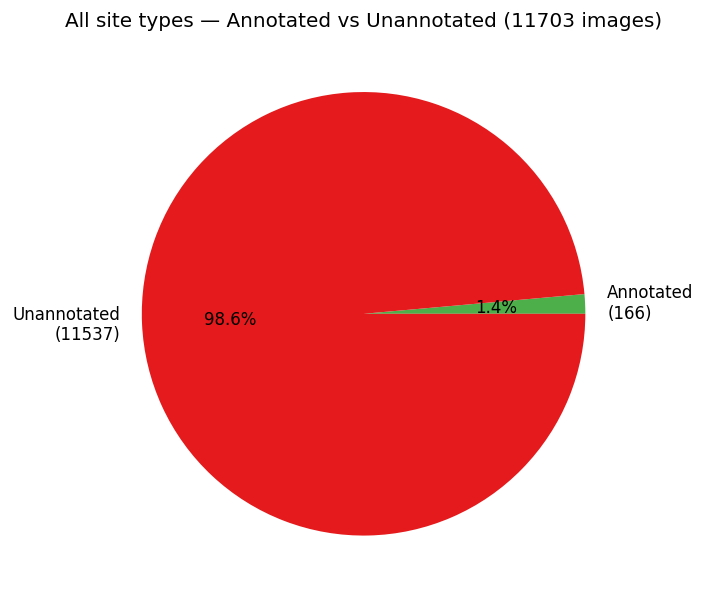

In [32]:
# Interactive pie chart: annotated vs not-annotated per site_type

# Prepare site_type options (fill NaN as "Unknown")
df_meta["_site_type_f"] = df_meta["site_type"].fillna("Unknown").astype(str)
site_opts = ["All"] + sorted(df_meta["_site_type_f"].unique().tolist(), key=str)

dd = widgets.Dropdown(options=site_opts, value=site_opts[0], description="site_type:")

def plot_site_pie(site):
    clear_output(wait=True)
    display(dd)  # keep the control visible

    if site == "All":
        sub = df_meta
        title = "All site types"
    else:
        sub = df_meta[df_meta["_site_type_f"] == site]
        title = f"site_type = {site}"

    if sub.shape[0] == 0:
        print(f"No images for {title}")
        return

    counts = sub["has_annotations"].value_counts().reindex([1, 0], fill_value=0)
    labels = ["Annotated", "Unannotated"]
    sizes = counts.values
    total = sizes.sum()

    # If no images, handle gracefully
    if total == 0:
        print(f"No images for {title}")
        return

    # Build label strings with counts
    labels_with_counts = [f"{lab}\n({int(cnt)})" for lab, cnt in zip(labels, sizes)]

    plt.figure(figsize=(6,6))
    plt.pie(sizes, labels=labels_with_counts, autopct=lambda pct: f"{pct:.1f}%", colors=["#4daf4a","#e41a1c"])
    plt.title(f"{title} — Annotated vs Unannotated ({total} images)")
    plt.show()

# Wire dropdown to plot
def on_change(change):
    if change["name"] == "value":
        plot_site_pie(change["new"])

dd.observe(on_change)
# initial display
plot_site_pie(dd.value)

### Labeled vs Unlabeled Sampling Bias

Compare the distribution of key metadata between labeled and unlabeled images to detect sampling bias. For categorical variables (site_type, severity, valid_fine_grain, evidence, is_candidate_location) we apply chi-square tests.

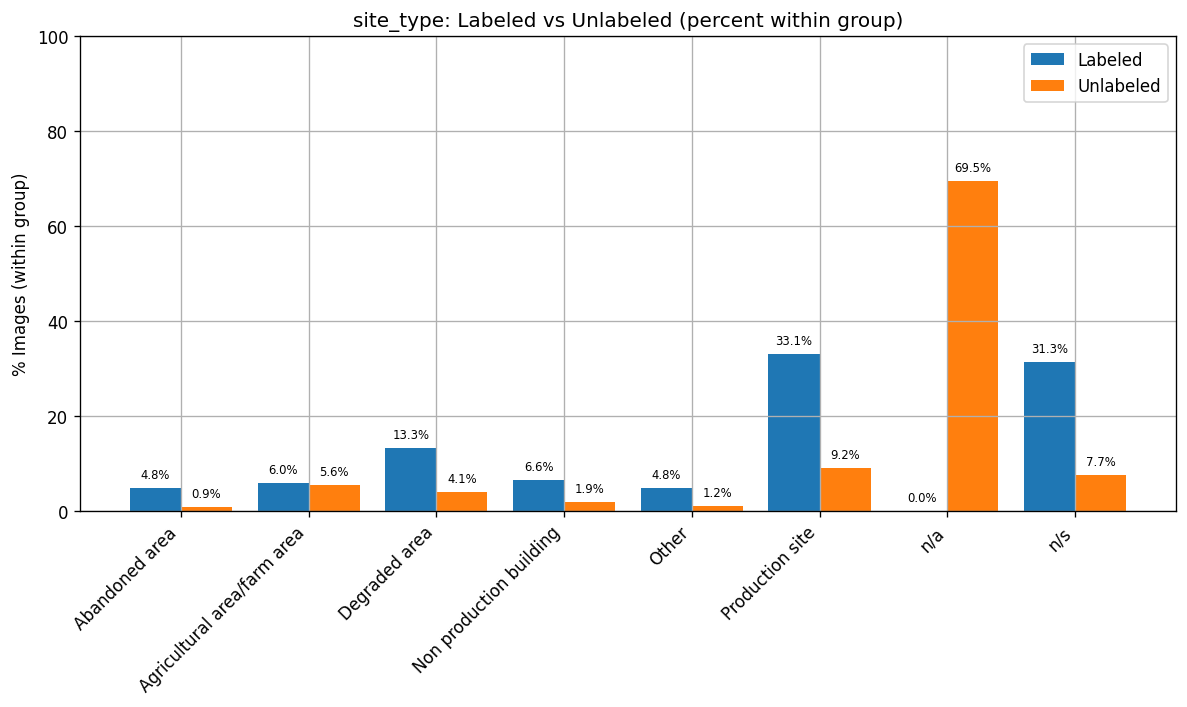

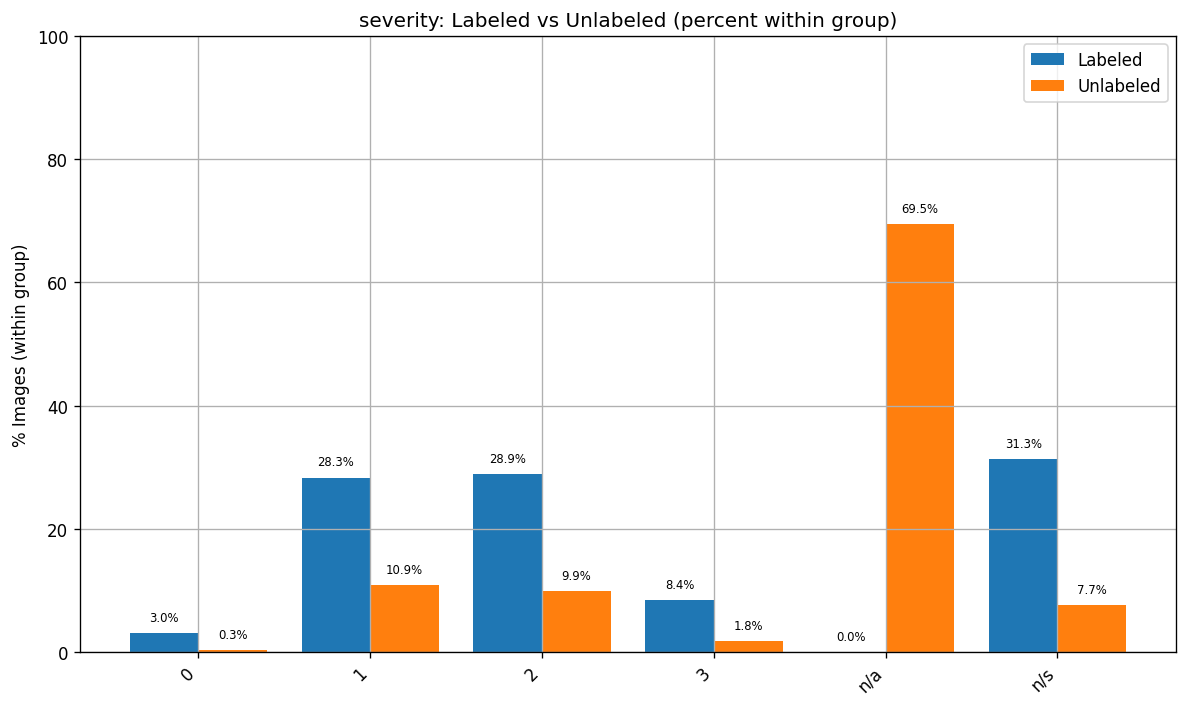

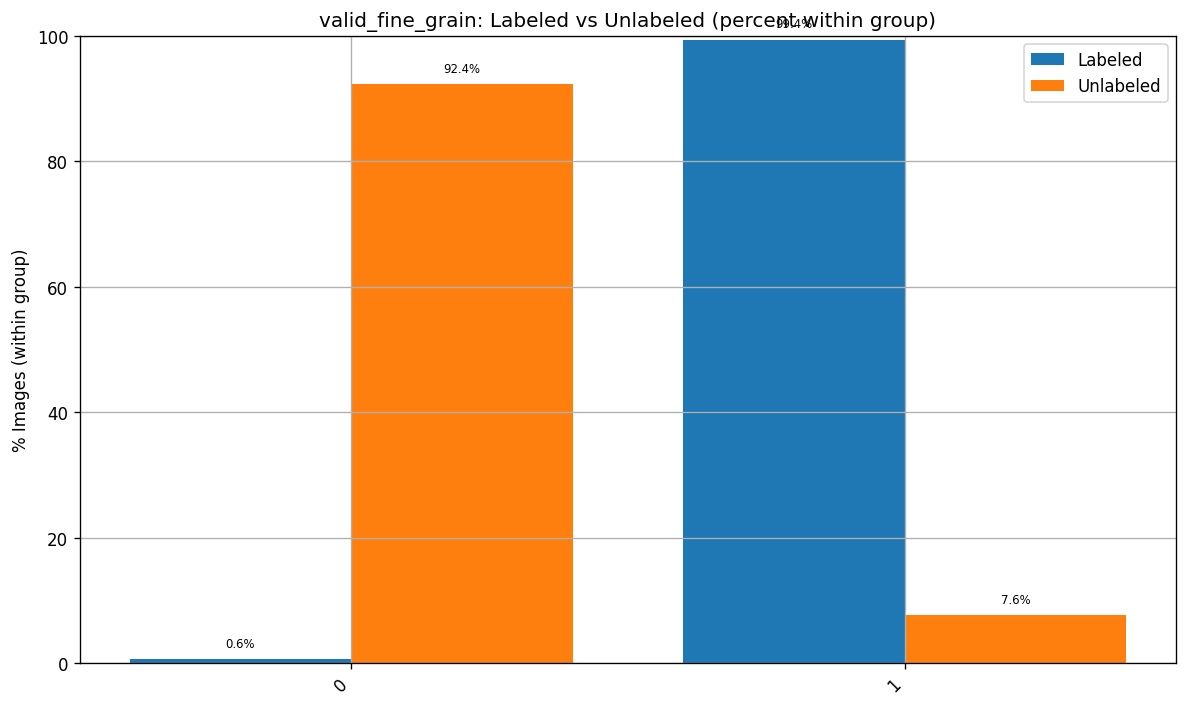

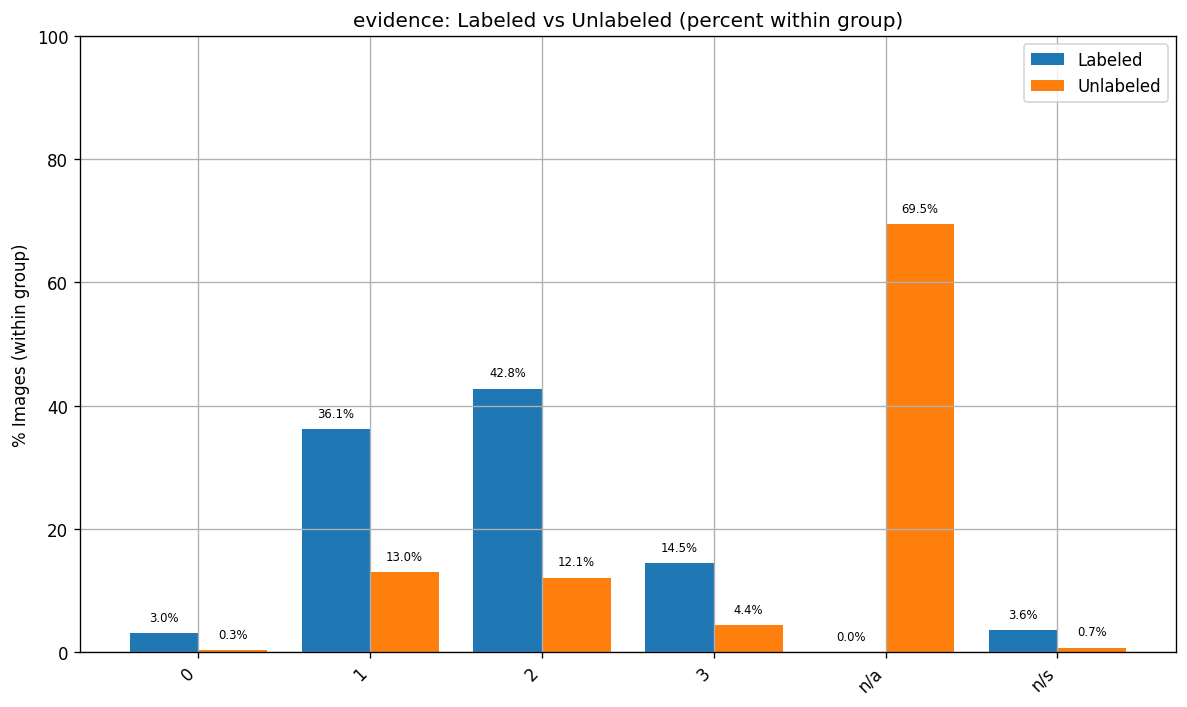

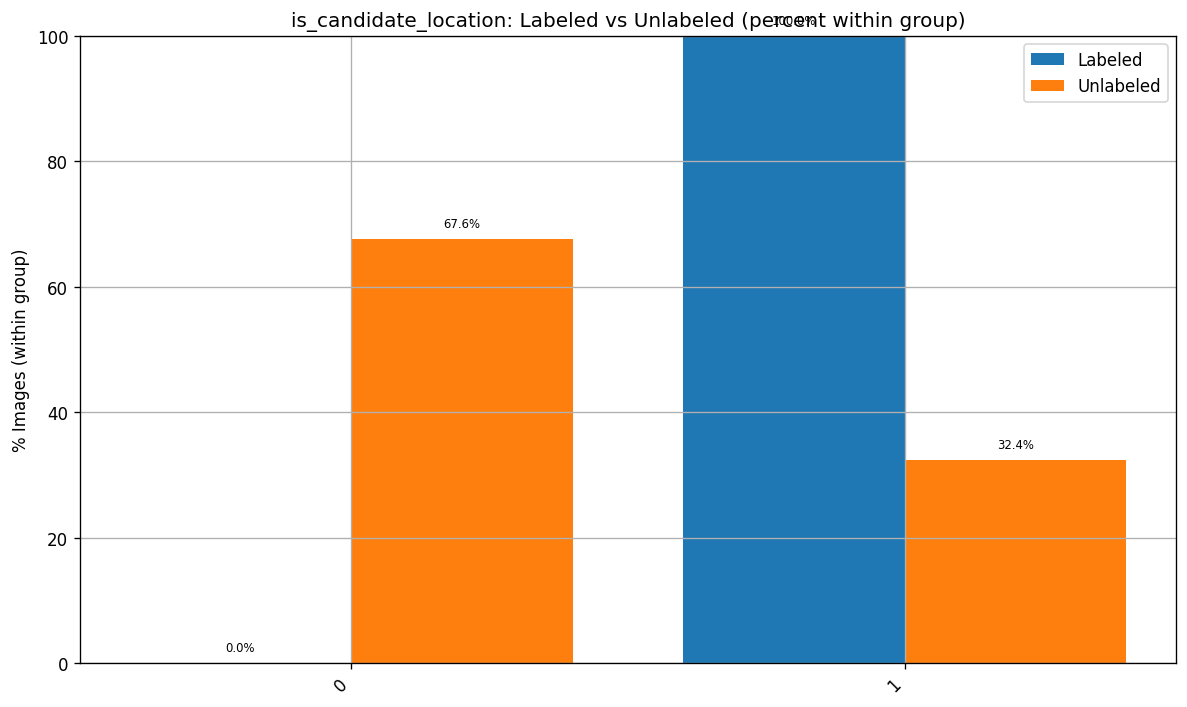

,feature,test,chi2,p_value,dof
0,site_type,chi-square,423.249738,2.454506e-87,7
1,severity,chi-square,407.662967,6.615677e-86,5
2,valid_fine_grain,chi-square,1679.952524,0.000000e+00,1
3,evidence,chi-square,393.201484,8.658316e-83,5
4,is_candidate_location,chi-square,333.740688,1.472564e-74,1


In [33]:
if not df_meta.empty:
    categorical_cols = ["site_type", "severity", "valid_fine_grain", "evidence", "is_candidate_location"]
    continuous_cols  = ["aspect_ratio"]

    # Categorical: chi-square tests + side-by-side relative bars (percent within group)
    chi_rows = []
    for col in categorical_cols:
        tab = pd.crosstab(df_meta[col].fillna("Unknown"), df_meta["has_annotations"])
        if tab.shape[0] > 1 and tab.shape[1] > 1:
            chi2, p, _, _ = chi2_contingency(tab)
            chi_rows.append({"feature": col, "test": "chi-square", "chi2": chi2, "p_value": p, "dof": tab.shape[0]-1})

        # Relative side-by-side bars (percent within labeled / unlabeled groups)
        counts_labeled = df_meta[df_meta["has_annotations"] == 1][col].value_counts()
        counts_unlab   = df_meta[df_meta["has_annotations"] == 0][col].value_counts()
        idx = sorted(set(counts_labeled.index).union(set(counts_unlab.index)), key=lambda x: str(x))

        total_l = counts_labeled.sum() if counts_labeled.sum() > 0 else 1
        total_u = counts_unlab.sum() if counts_unlab.sum() > 0 else 1

        lab_vals = [counts_labeled.get(i, 0) / total_l * 100.0 for i in idx]
        unlab_vals = [counts_unlab.get(i, 0)   / total_u * 100.0 for i in idx]

        plt.figure()
        x = np.arange(len(idx))
        width = 0.4
        plt.bar(x - width/2, lab_vals,  width, label="Labeled")
        plt.bar(x + width/2, unlab_vals, width, label="Unlabeled")
        plt.xticks(x, [str(i) for i in idx], rotation=45, ha="right")
        plt.title(f"{col}: Labeled vs Unlabeled (percent within group)")
        plt.ylabel("% Images (within group)")
        plt.ylim(0, 100)
        plt.legend()
        plt.tight_layout()

        # annotate bars with percent values
        for xi, v in zip(x - width/2, lab_vals):
            plt.text(xi, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)
        for xi, v in zip(x + width/2, unlab_vals):
            plt.text(xi, v + 1.5, f"{v:.1f}%", ha="center", va="bottom", fontsize=7)

        plt.show()

    df_chi = pd.DataFrame(chi_rows)
    display(df_chi)

Chi-square tests show strong, statistically significant differences between labeled and unlabeled images across all categorical features (site_type, severity, valid_fine_grain, evidence, is_candidate_location).

All p-values are far below 0.05, indicating that the labeled subset is not representative of the overall dataset.
In practice, this means certain categories are over- or underrepresented in the labeled data, suggesting sampling bias that could affect model generalization.

### Supercategory Roll-ups & Cross-tab (Type_of_object vs Storage_mode)

The dataset’s categories are grouped into supercategories that represent two distinct labeling axes: Type_of_object (e.g., Plastic, Rubble, Tires) and Storage_mode (e.g., Heaps not delimited, Full container, Big bags). In this section we aggregate annotations by supercategory to quantify how many labeled instances belong to each axis and how prominent each axis is overall. We then build a cross-tabulation of Type_of_object versus Storage_mode at the image level to measure how often specific object types co-occur with specific storage modes within the same scene. This reveals whether storage is merely contextual or behaves like a second label dimension, and it helps decide modeling strategy (single-head vs multi-head, single-label vs multi-label), guide sampling/augmentation (e.g., under-represented Type×Storage combinations), and shape evaluation (e.g., stratified metrics by axis or by their joint distribution).

In [34]:
# Map: category_id -> supercategory
super_by_cid = {c["id"]: c.get("supercategory", "") for c in cats}

In [35]:
# Count instances per supercategory
super_counts = Counter()
for a in annotations_all:
    sc = super_by_cid.get(a.get("category_id"), "")
    super_counts[sc] += 1

df_super = pd.DataFrame(
    [{"supercategory": k, "instances": v} for k, v in super_counts.items()]
).sort_values("instances", ascending=False)
display(df_super)

,supercategory,instances
0,Storage_mode,471
1,Type_of_object,362


In [36]:
# Cross-tab: Type_of_object (rows) x Storage_mode (cols), measured at image level
img_to_superset = defaultdict(set)
for a in annotations_all:
    sup = super_by_cid.get(a.get("category_id"), "")
    img_to_superset[a["image_id"]].add((a.get("category_id"), sup))

pair_ts_counter = Counter()
for img_id, pairs in img_to_superset.items():
    types   = {cid for cid, sup in pairs if sup == "Type_of_object"}
    storage = {cid for cid, sup in pairs if sup == "Storage_mode"}
    if types and storage:
        for t in types:
            for s in storage:
                pair_ts_counter[(t, s)] += 1

rows = []
for (t, s), cnt in pair_ts_counter.items():
    t_name = cat_by_id.get(t, {}).get("name", t)
    s_name = cat_by_id.get(s, {}).get("name", s)
    rows.append({"type_id": t, "type_name": t_name, "storage_id": s, "storage_name": s_name, "images_with_both": cnt})
df_type_storage = pd.DataFrame(rows)

if not df_type_storage.empty:
    ctab = df_type_storage.pivot_table(
        index="type_name", columns="storage_name", values="images_with_both",
        aggfunc="sum", fill_value=0
    )
    display(ctab)
else:
    print("No co-occurrence between Type_of_object and Storage_mode found in the current annotations.")

storage_name,Big bags,Delimited heaps (by barriers/walls/etc),Full container,Heaps not delimited
type_name,,,,
Bulky items,4,9,17,30
Fire Wood,4,6,7,16
Rubble/excavated earth and rocks,1,9,18,49
Tires,1,4,5,11
Vehicles,1,6,5,14


### Category Inventory & Class Balance

Characterize class balance and co-occurrence. We report per-category instance counts and the number of distinct images in which each category appears. We also show the distribution of objects per image and the most frequent category pairs, informing sampling, reweighting, and evaluation design.

In [37]:
# Per-category instance counts and images-with-class
inst_counter = Counter()
imgs_with_class = defaultdict(set)

for a in annotations_all:
    cid = a.get("category_id")
    inst_counter[cid] += 1
    imgs_with_class[cid].add(a["image_id"])

rows = []
for cid, cinfo in cat_by_id.items():
    inst = inst_counter.get(cid, 0)
    imgs = len(imgs_with_class.get(cid, set()))
    rows.append({
        "category_id": cid,
        "category_name": cinfo.get("name", f"id={cid}"),
        "supercategory": cinfo.get("supercategory", ""),
        "instances": inst,
        "images_with_class": imgs,
        "pct_of_instances": (inst / max(sum(inst_counter.values()), 1)) * 100.0
    })

df_cat = pd.DataFrame(rows).sort_values("instances", ascending=False)
display(df_cat)

,category_id,category_name,supercategory,instances,images_with_class,pct_of_instances
16,17,Full container,Storage_mode,185,55,22.208884
15,16,Heaps not delimited,Storage_mode,171,94,20.528211
0,1,Rubble/excavated earth and rocks,Type_of_object,126,64,15.126050
5,6,Vehicles,Type_of_object,69,26,8.283313
1,2,Bulky items,Type_of_object,69,45,8.283313
2,3,Fire Wood,Type_of_object,62,37,7.442977
17,18,Big bags,Storage_mode,60,17,7.202881
19,20,Delimited heaps (by barriers/walls/etc),Storage_mode,55,33,6.602641
6,7,Tires,Type_of_object,36,15,4.321729
13,14,Corrugated sheets (presumed asbestos-cement),Type_of_object,0,0,0.000000


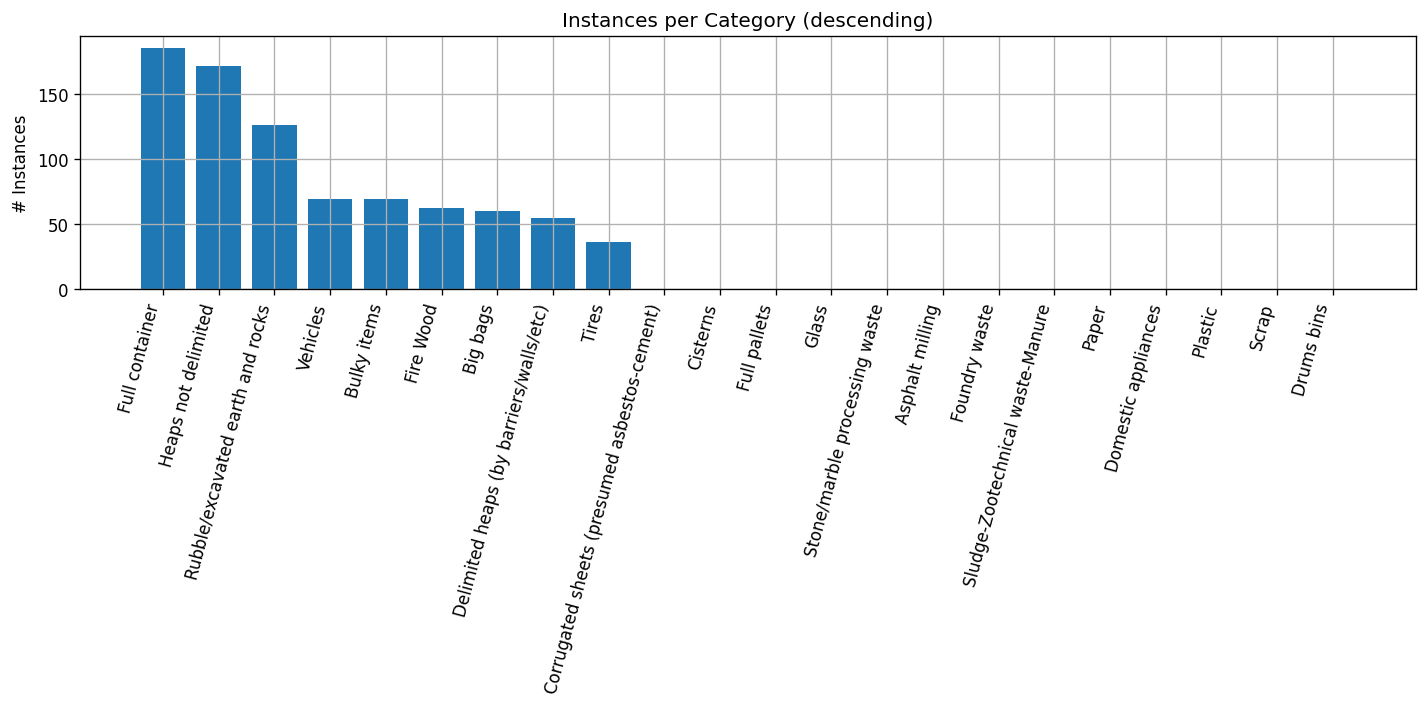

In [38]:
# Bar plot: instances per category (descending)
plt.figure(figsize=(12, 6))
plt.bar(df_cat["category_name"], df_cat["instances"])
plt.xticks(rotation=75, ha="right")
plt.title("Instances per Category (descending)")
plt.ylabel("# Instances")
plt.tight_layout()
plt.show()

- The dataset (as labeled so far) is strongly imbalanced and axis-skewed toward Storage_mode labels.

- Several Type_of_object categories are unseen; training a multi-class detector across all 22 classes will lead to severe data sparsity for many labels and unreliable per-class metrics.

In [39]:
# Co-occurrence (top pairs)
img_to_cset = defaultdict(set)
for a in annotations_all:
    img_to_cset[a["image_id"]].add(a["category_id"])

pair_counter = Counter()
for cset in img_to_cset.values():
    for comb in combinations(sorted(cset), 2):
        pair_counter[comb] += 1

In [40]:
top_pairs = pair_counter.most_common(20)
df_pairs = pd.DataFrame([
    {
        "cat1_id": p[0][0],
        "cat1_name": cat_by_id.get(p[0][0], {}).get("name", p[0][0]),
        "cat2_id": p[0][1],
        "cat2_name": cat_by_id.get(p[0][1], {}).get("name", p[0][1]),
        "images_together": p[1]
    }
    for p in top_pairs
])
display(df_pairs)

,cat1_id,cat1_name,cat2_id,cat2_name,images_together
0,1,Rubble/excavated earth and rocks,16,Heaps not delimited,49
1,2,Bulky items,16,Heaps not delimited,30
2,16,Heaps not delimited,17,Full container,29
3,17,Full container,20,Delimited heaps (by barriers/walls/etc),19
4,16,Heaps not delimited,20,Delimited heaps (by barriers/walls/etc),18
5,1,Rubble/excavated earth and rocks,17,Full container,18
6,1,Rubble/excavated earth and rocks,2,Bulky items,18
7,2,Bulky items,17,Full container,17
8,3,Fire Wood,16,Heaps not delimited,16
9,6,Vehicles,16,Heaps not delimited,14


### Annotation Geometry Hygiene

This section validates the numerical correctness and geometric plausibility of training boxes, whether they are provided natively as bbox = [x, y, width, height] (pixels, top-left origin) or derived from segmentation when native boxes are absent. Concretely, for each annotation we use the COCO bbox if present; otherwise we compute a tight bounding box from the segmentation polygon (and from RLE masks when available), then audit the result. We first check for invalid boxes (non-positive width/height) and for coordinates exceeding image bounds, quantifying how many would require clipping to the image canvas. For every valid (post-clip) box we compute the relative area (w·h / W·H), indicating target size within its image, and the aspect ratio (w/h), summarizing shape (wide, tall, near-square). We report totals (boxes scanned, % invalid, % clipped) and visualize the distributions of relative area and aspect ratio; these inform detector design choices such as input resolution, tiling, multi-scale policy, and (for anchor-based models) anchor suitability. By default, the analysis runs on the currently selected annotation source (e.g., patches_labels.json if patches carry the labels, or train/test JSONs otherwise), and the same computations can be repeated per split to independently audit train, validation, and test quality.

In [41]:
def choose_source(train_data, test_data, patches_data):
    """Pick the annotation source with actual labels. Prefer patches if they have more."""
    cand = []
    if train_data:
        cand.append(("train", len(train_data.get("annotations", [])), train_data))
    if test_data:
        cand.append(("test", len(test_data.get("annotations", [])), test_data))
    if patches_data:
        cand.append(("patches", len(patches_data.get("annotations", [])), patches_data))
    if not cand:
        return None, [], [], []
    # Prefer the one with the most annotations; tie-breaker: patches > train > test
    cand.sort(key=lambda x: (x[1], x[0]=="patches", x[0]=="train"), reverse=True)
    name, n, data = cand[0]
    imgs, anns, cats = data.get("images", []), data.get("annotations", []), data.get("categories", [])
    return name, imgs, anns, cats

src_name, SRC_IMAGES, SRC_ANN, SRC_CATS = choose_source(train_data, test_data, patches_data)
print(f"Using annotations from: {src_name if src_name else 'NONE'}")
print(f"Images: {len(SRC_IMAGES)}, Annotations: {len(SRC_ANN)}, Categories: {len(SRC_CATS)}")

Using annotations from: test
Images: 2607, Annotations: 833, Categories: 22


In [42]:
# Indexes
src_img_by_id = {im["id"]: im for im in SRC_IMAGES}
src_cat_by_id = {c["id"]: c for c in SRC_CATS}

In [43]:
# --- converters ---
def poly_to_bbox(segmentation):
    """
    segmentation: list of polygons; each polygon is [x1,y1,x2,y2,...].
    Return [x, y, w, h] or None.
    """
    if not isinstance(segmentation, list) or len(segmentation) == 0:
        return None
    xs, ys = [], []
    for poly in segmentation:
        if not poly or len(poly) < 6:
            continue
        xs.extend(poly[0::2])
        ys.extend(poly[1::2])
    if not xs or not ys:
        return None
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    w, h = x_max - x_min, y_max - y_min
    if w <= 0 or h <= 0:
        return None
    return [float(x_min), float(y_min), float(w), float(h)]

def rle_to_bbox(segm_rle):
    """
    segm_rle: RLE dict with keys 'size' and 'counts' (COCO format).
    Return [x, y, w, h] or None. Requires pycocotools.
    """
    if not HAS_COCO_TOOLS:
        return None
    try:
        rle = segm_rle
        if isinstance(rle.get("counts"), list):  # uncompressed RLE
            rle = maskUtils.frPyObjects([rle], rle["size"][0], rle["size"][1])[0]
        bb = maskUtils.toBbox(rle)  # returns [x, y, w, h] float
        x, y, w, h = [float(v) for v in bb]
        if w <= 0 or h <= 0:
            return None
        return [x, y, w, h]
    except Exception:
        return None

def any_to_bbox(ann):
    """
    Try bbox; else polygon; else RLE. Return [x,y,w,h] or None.
    """
    if "bbox" in ann and isinstance(ann["bbox"], (list, tuple)) and len(ann["bbox"]) == 4:
        x, y, w, h = ann["bbox"]
        if w > 0 and h > 0:
            return [x, y, w, h]
    # polygon segmentation
    seg = ann.get("segmentation")
    if isinstance(seg, list) and seg:
        bb = poly_to_bbox(seg)
        if bb is not None:
            return bb
    # rle segmentation
    if isinstance(seg, dict) and seg.get("counts") is not None:
        bb = rle_to_bbox(seg)
        if bb is not None:
            return bb
    return None

def clip_box(x, y, w, h, W, H):
    x2, y2 = x + w, y + h
    x  = max(0.0, min(x,  W))
    y  = max(0.0, min(y,  H))
    x2 = max(0.0, min(x2, W))
    y2 = max(0.0, min(y2, H))
    w = max(0.0, x2 - x)
    h = max(0.0, y2 - y)
    clipped = (x2 < x + w) or (y2 < y + h)  # simple change detector
    return x, y, w, h, clipped

In [44]:
# --- hygiene pass over chosen source ---
records = []
invalid_area = 0
clipped_count = 0
total = 0
from_polygon = 0
from_rle = 0

for a in SRC_ANN:
    img = src_img_by_id.get(a["image_id"])
    if not img:
        continue
    W, H = img.get("width"), img.get("height")
    if not W or not H:
        continue

    bb = None
    # direct bbox?
    if "bbox" in a and isinstance(a["bbox"], (list, tuple)) and len(a["bbox"])==4 and a["bbox"][2] > 0 and a["bbox"][3] > 0:
        bb = a["bbox"]
    else:
        seg = a.get("segmentation")
        if isinstance(seg, list) and seg:
            bb = poly_to_bbox(seg); from_polygon += int(bb is not None)
        elif isinstance(seg, dict) and seg.get("counts") is not None:
            bb = rle_to_bbox(seg); from_rle += int(bb is not None)

    if bb is None:
        continue

    x, y, w, h = bb
    total += 1
    raw_valid = (w > 0) and (h > 0)
    if not raw_valid:
        invalid_area += 1

    x_c, y_c, w_c, h_c, clipped = clip_box(x, y, w, h, W, H)
    if clipped:
        clipped_count += 1

    area_rel = (w_c * h_c) / max(W * H, 1)
    ar = (w_c / h_c) if h_c > 0 else np.inf

    records.append({
        "image_id": a["image_id"],
        "category_id": a.get("category_id"),
        "post_w": w_c, "post_h": h_c,
        "clipped": int(clipped),
        "raw_valid": int(raw_valid),
        "area_rel": area_rel,
        "aspect_ratio": ar
    })


In [45]:
# --- Safe COCO tools import ---
try:
    import pycocotools.mask as mask_utils
    HAS_COCO_TOOLS = True
except Exception:
    HAS_COCO_TOOLS = False

print(f"HAS_COCO_TOOLS = {HAS_COCO_TOOLS}")

HAS_COCO_TOOLS = True


In [46]:
df_bbox = pd.DataFrame(records)
print(f"Total boxes usable (any source): {total}")
print(f"Derived from polygons: {from_polygon}")
print(f"Derived from RLE: {from_rle}{'' if HAS_COCO_TOOLS else ' (pycocotools not installed → RLE skipped)'}")
print(f"Invalid (non-positive area): {invalid_area} ({100.0 * invalid_area / max(total,1):.2f}%)")
print(f"Clipped to bounds: {clipped_count} ({100.0 * clipped_count / max(total,1):.2f}%)")

display(df_bbox.head())

Total boxes usable (any source): 833
Derived from polygons: 833
Derived from RLE: 0
Invalid (non-positive area): 0 (0.00%)
Clipped to bounds: 0 (0.00%)


,image_id,category_id,post_w,post_h,clipped,raw_valid,area_rel,aspect_ratio
0,662,17,36.760447,26.167553,0,1,0.000962,1.404810
1,662,17,179.853780,64.143307,0,1,0.011536,2.803937
2,662,17,30.830300,17.500000,0,1,0.000540,1.761731
3,842,17,15.244860,31.801267,0,1,0.000485,0.479379
4,842,17,17.504613,32.169947,0,1,0.000563,0.544129


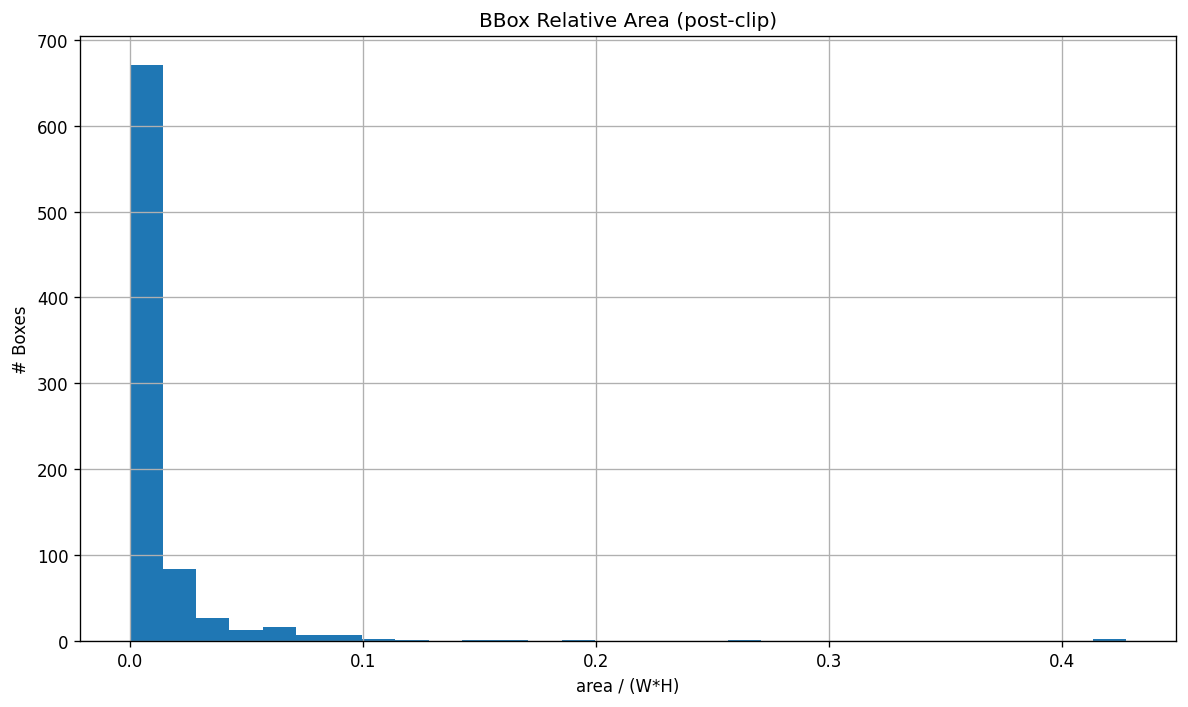

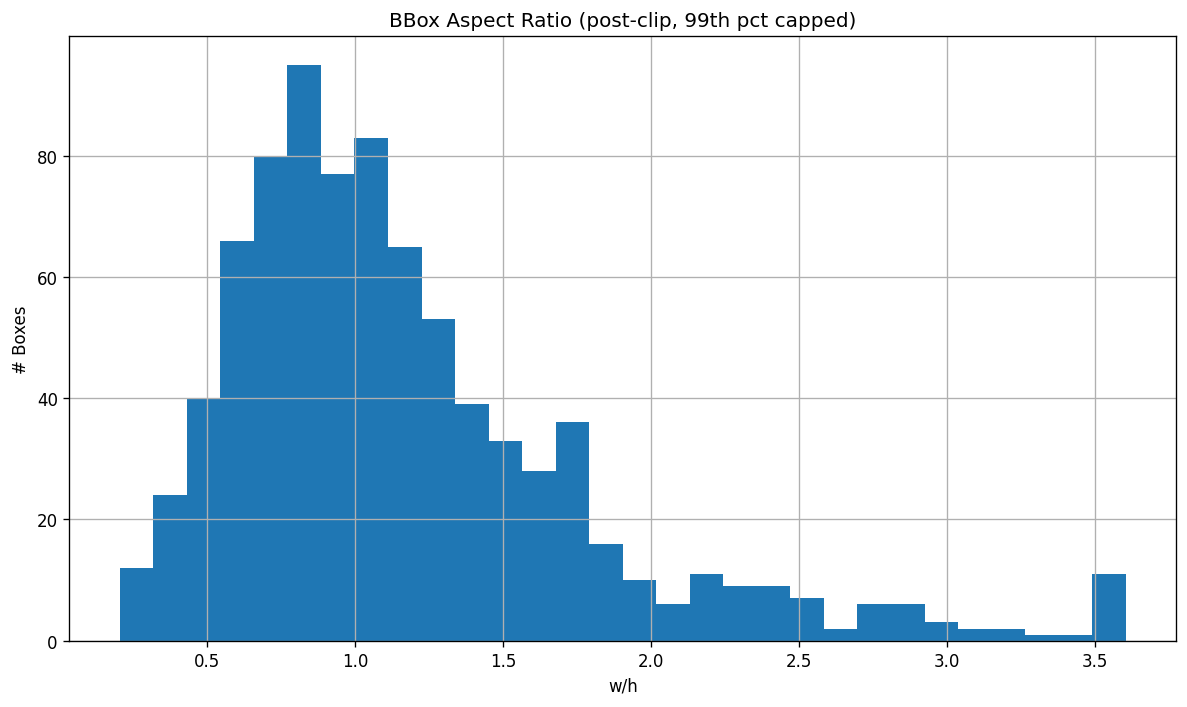

In [47]:
if not df_bbox.empty:
    plt.figure()
    plt.hist(df_bbox["area_rel"].clip(0,1), bins=30)
    plt.title("BBox Relative Area (post-clip)")
    plt.xlabel("area / (W*H)")
    plt.ylabel("# Boxes")
    plt.tight_layout()
    plt.show()

    finite_ar = df_bbox[np.isfinite(df_bbox["aspect_ratio"])]["aspect_ratio"].values
    if len(finite_ar):
        plt.figure()
        cap = np.percentile(finite_ar, 99)
        plt.hist(np.clip(finite_ar, 0, cap), bins=30)
        plt.title("BBox Aspect Ratio (post-clip, 99th pct capped)")
        plt.xlabel("w/h")
        plt.ylabel("# Boxes")
        plt.tight_layout()
        plt.show()

A total of 833 bounding boxes were extracted from polygon annotations (no invalid or clipped boxes).
Most boxes cover less than 1 % of the image area, indicating that the objects are small relative to the image.
The aspect ratios cluster around 1.0, with some wider boxes up to ~3.5, meaning most objects are roughly square with a few rectangular ones.
Overall, the dataset contains small, well-defined objects, suitable for small-object detection tasks.

# APPENDIX

### Negative Images & Hard Negatives

Quantify images with zero annotations (negatives) and profile them by site_type and other flags to identify hard negatives (images that are visually similar to positives but unlabeled). Including a representative set of hard negatives in validation helps stress-test the detector against false positives and improves robustness. We report counts of negatives overall and by site_type, and display a short list of example IDs for qualitative review.

In [48]:
# 1) Identify negatives
df_neg = df_meta[df_meta["has_annotations"] == 0].copy()
print(f"Negatives (0 annotations): {len(df_neg)} / {len(df_meta)} images.")

Negatives (0 annotations): 11537 / 11703 images.


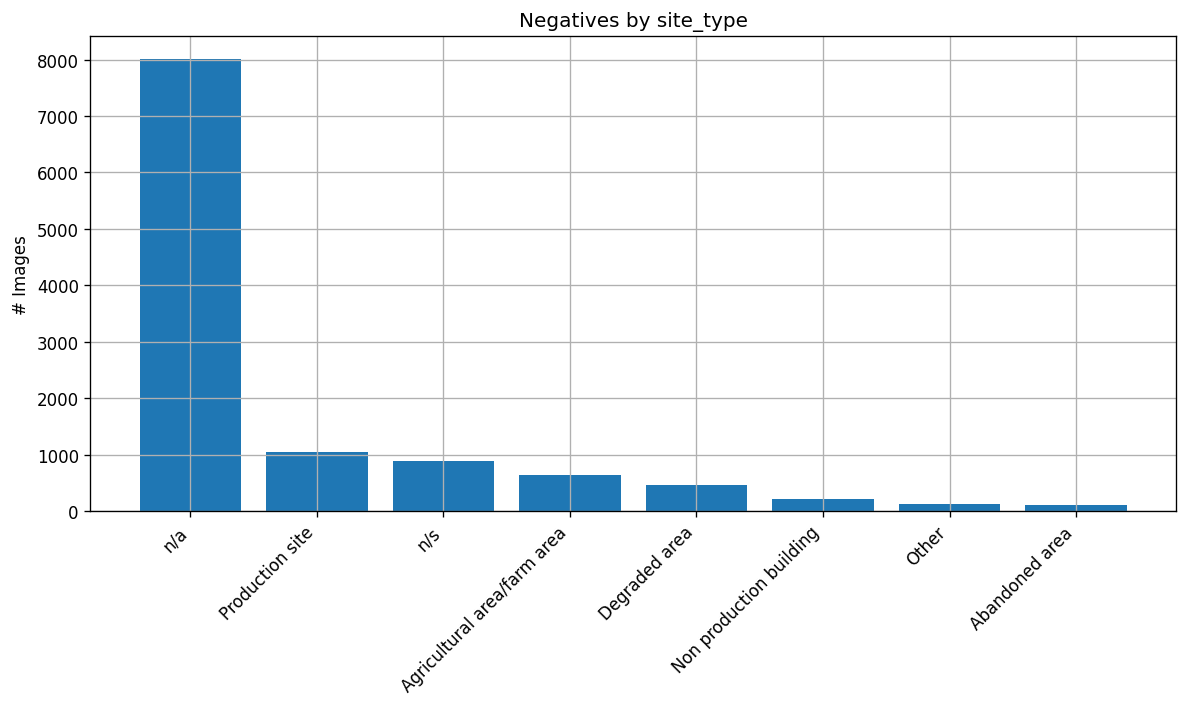

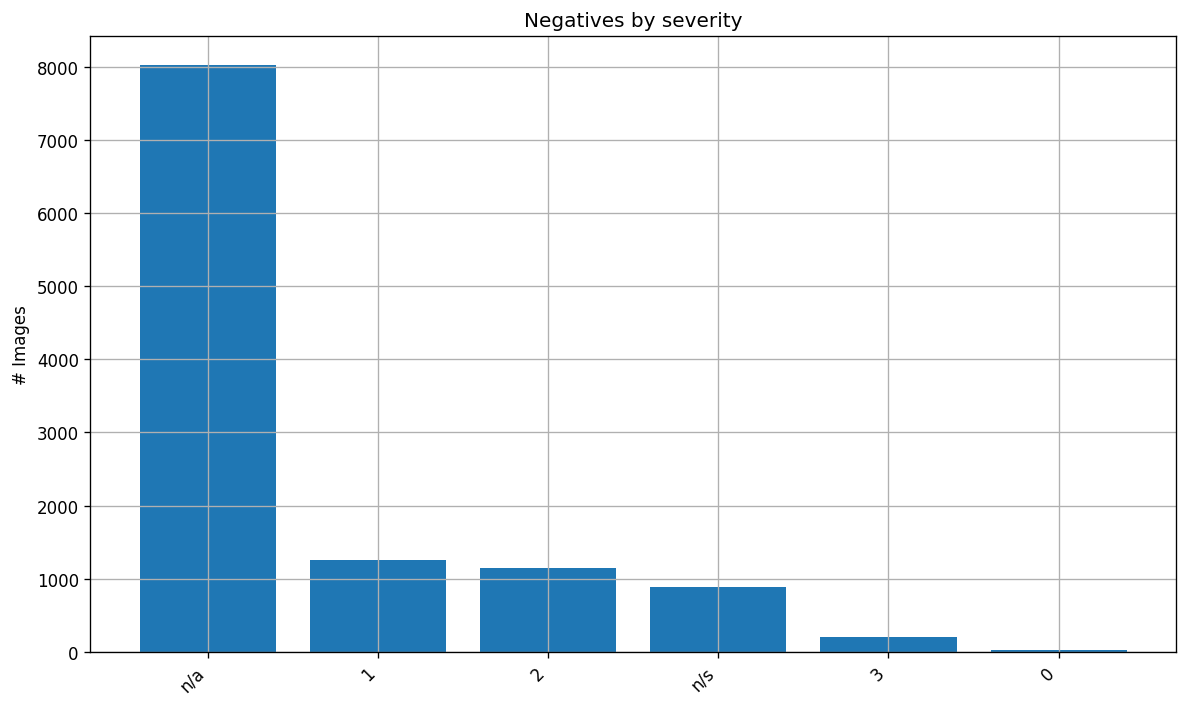

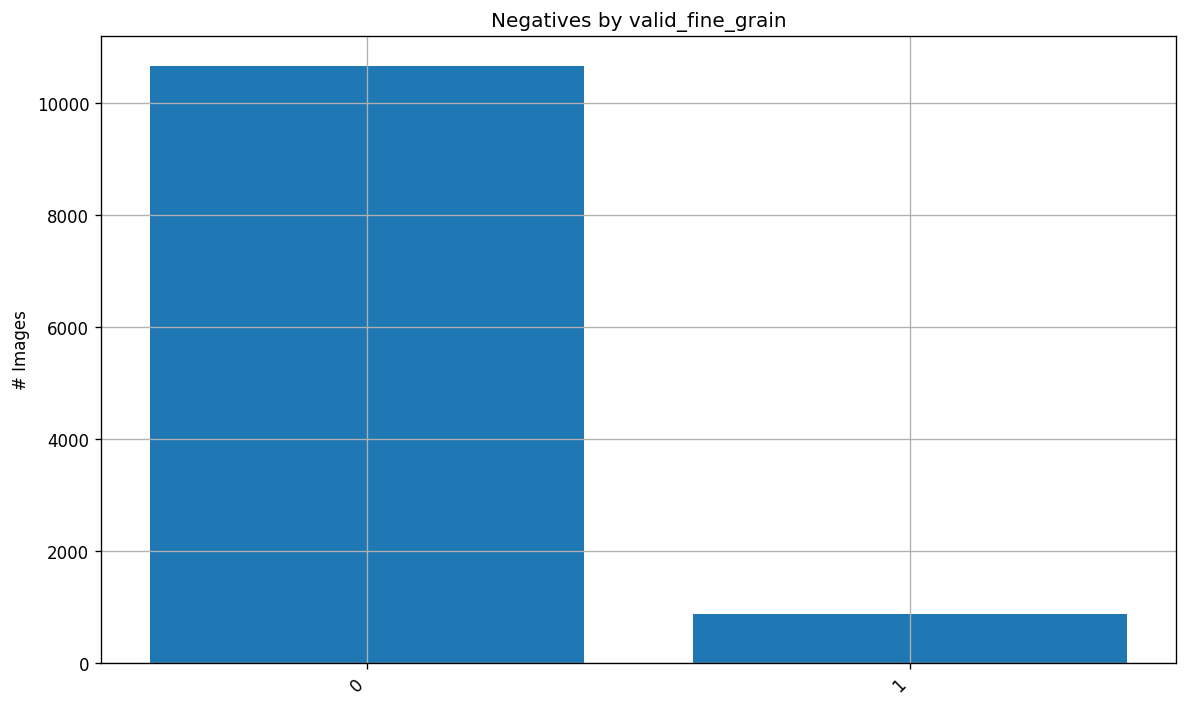

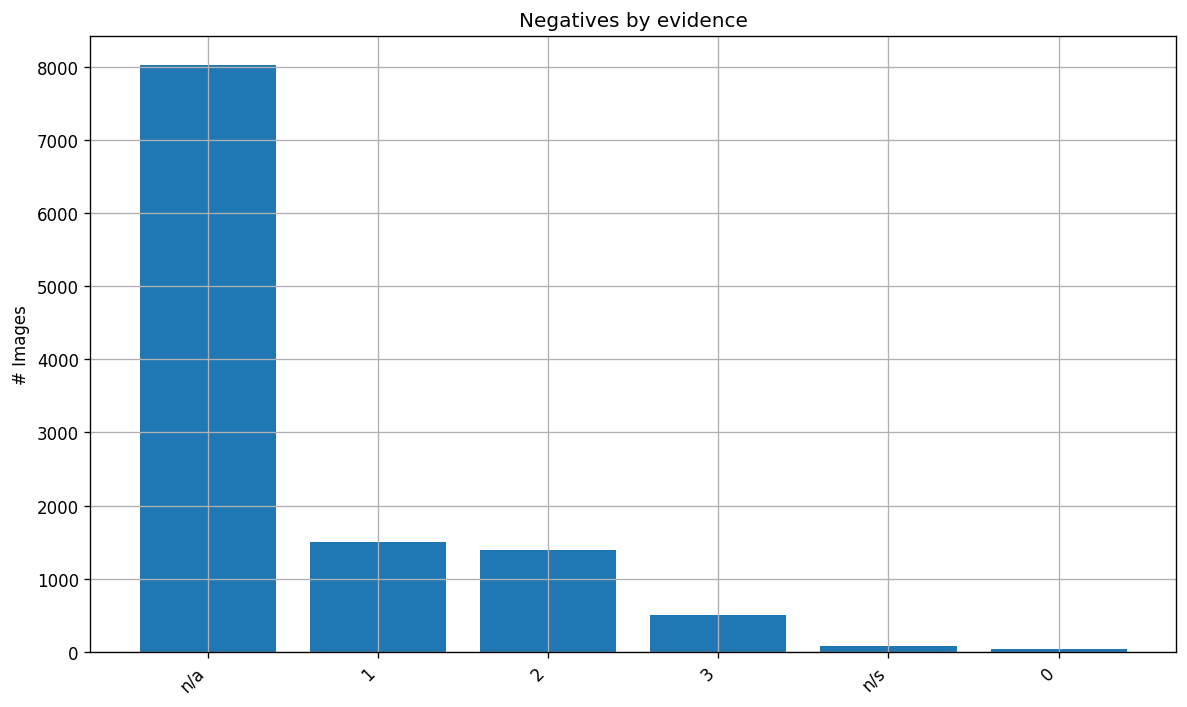

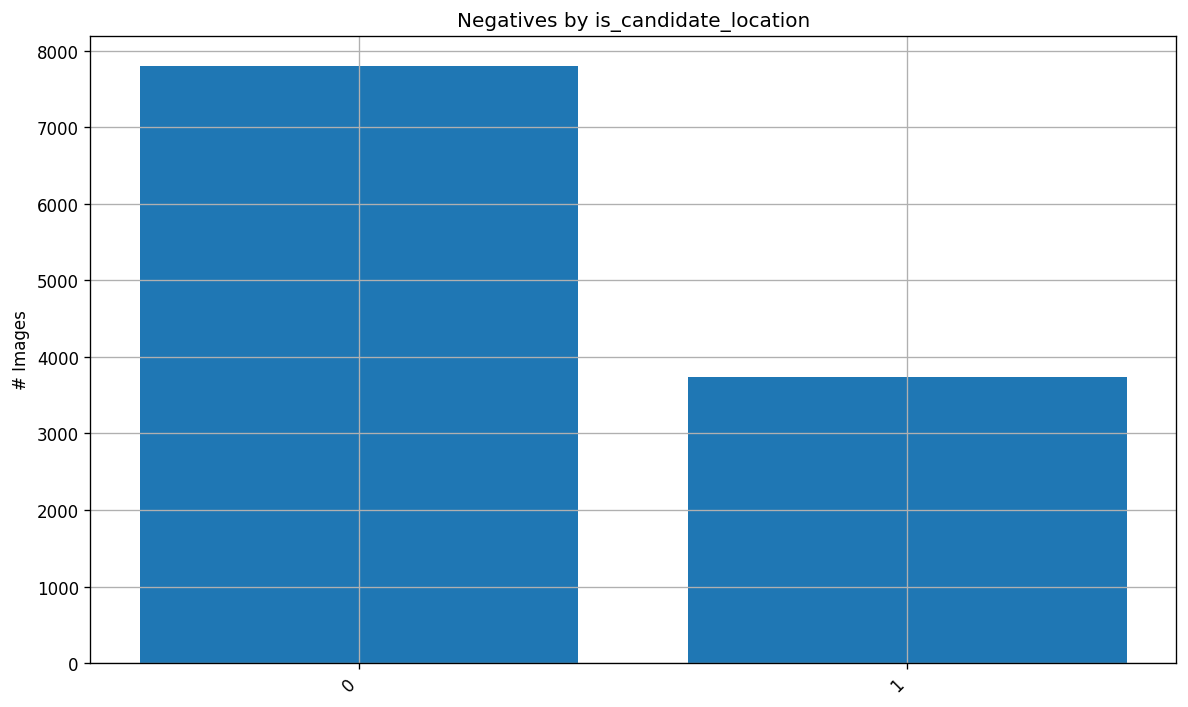

In [49]:
# 2) Stratify negatives by site_type and flags (top bar plot)
for col in ["site_type", "severity", "valid_fine_grain", "evidence", "is_candidate_location"]:
    counts = df_neg[col].value_counts(dropna=False)
    if counts.empty:
        continue
    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Negatives by {col}")
    plt.ylabel("# Images")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [50]:
# 3) Sample a few representative negatives for a quick qualitative check
sample_neg = df_neg.sample(min(12, len(df_neg)), random_state=42) if len(df_neg) else df_neg
display(sample_neg[["image_id","file_name","site_type","severity","evidence","is_candidate_location"]])

,image_id,file_name,site_type,severity,evidence,is_candidate_location
5187,6767,6767.png,n/a,n/a,n/a,1
6260,8165,8165.png,Degraded area,1,1,0
2069,2717,2717.png,n/s,n/s,2,1
7259,9424,9424.png,n/a,n/a,n/a,0
4995,6524,6524.png,n/a,n/a,n/a,0
7070,9190,9190.png,n/a,n/a,n/a,0
6535,8520,8520.png,Production site,1,2,1
5609,7317,7317.png,n/a,n/a,n/a,0
5340,6969,6969.png,n/a,n/a,n/a,0
1941,2532,2532.png,n/s,n/s,3,1


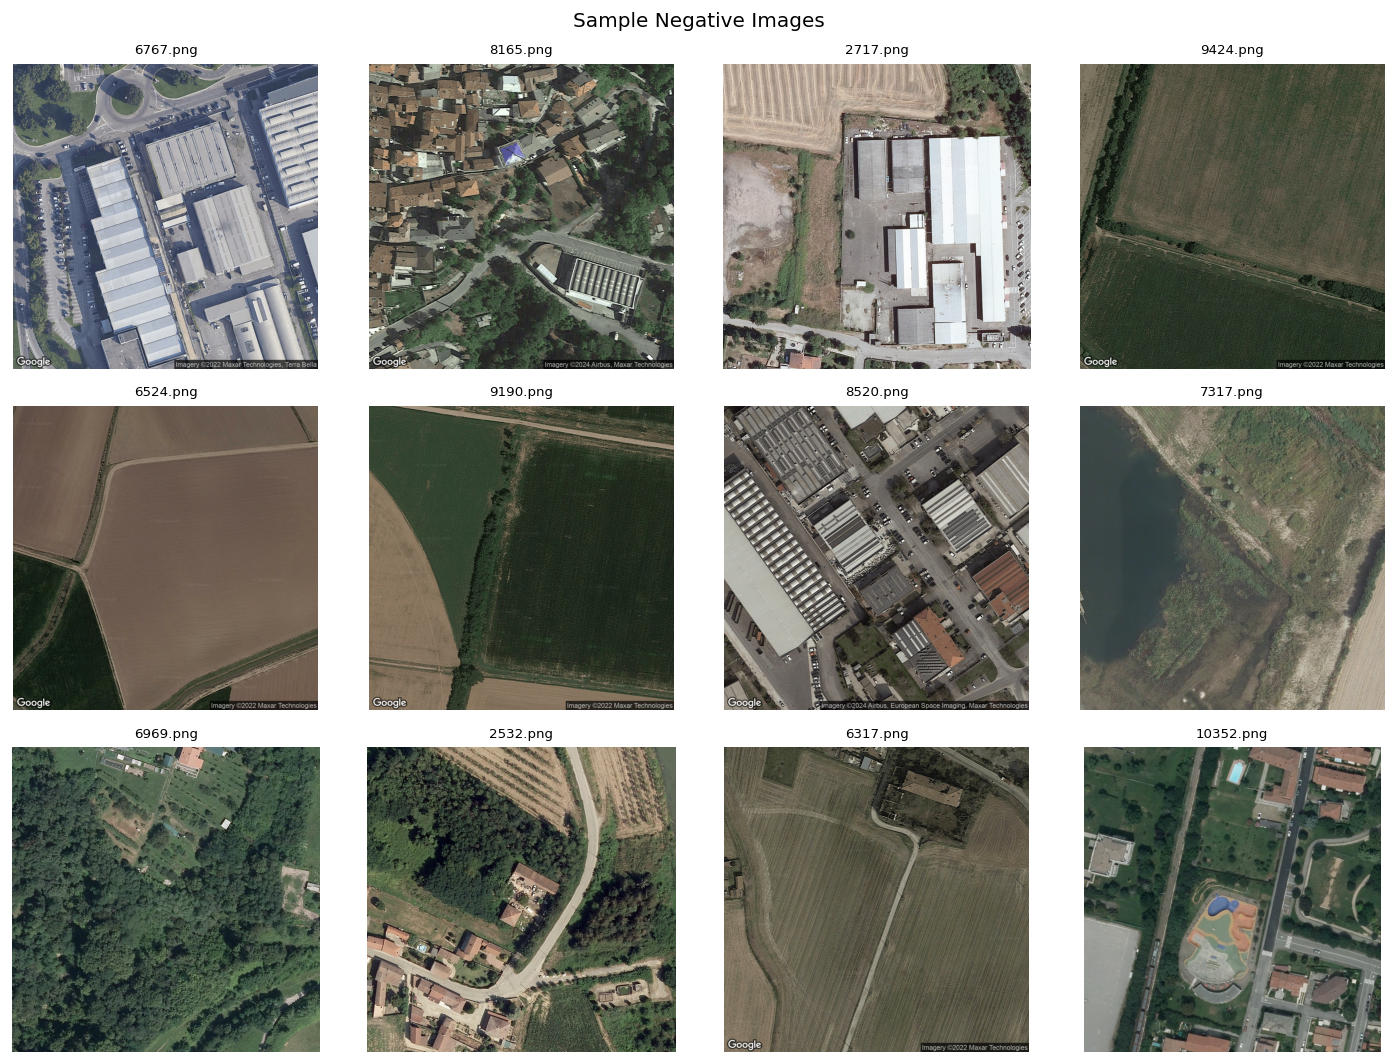

In [51]:
# Show thumbnails of sampled negatives
if len(sample_neg):
    cols = 4
    rows = math.ceil(len(sample_neg) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = np.array(axes).reshape(-1) if isinstance(axes, np.ndarray) else [axes]
    for ax, (_, row) in zip(axes, sample_neg.iterrows()):
        p = IMAGES_DIR / row["file_name"]
        try:
            with Image.open(p) as im:
                ax.imshow(im)
                ax.set_title(row["file_name"], fontsize=8)
                ax.axis("off")
        except:
            ax.axis("off")
    for ax in axes[len(sample_neg):]:
        ax.axis("off")
    plt.suptitle("Sample Negative Images")
    plt.tight_layout()
    plt.show()